# Hybrid and Explainable Machine Learning for LAI Polymer Drug Release

## 1. Introduction

Long-acting injectable (LAI) polymer formulations are designed to release drug over extended time periods, but release profiles depend jointly on formulation, polymer, drug, and time-dependent degradation or diffusion processes. This notebook converts the preliminary Orange analysis into a reproducible Python workflow suitable for an academic paper.

The analysis is organized around ten paper sections: dataset and Orange baseline, reproducible Python workflow, grouped model comparison, zero-shot versus few-shot prediction, full profile prediction by varying only `Time`, SHAP explainability, hybrid kinetic ML, uncertainty and monotonic correction, and mechanistic chemistry interpretation.

**Main project idea:** predict cumulative fractional release from formulation/drug descriptors, compare zero-shot and few-shot settings, and connect the strongest ML model to interpretable release mechanisms.

### Notebook setup

Run this cell in Colab or a fresh local environment. If the packages are already installed, the cell does nothing.

In [155]:
import importlib.util
import shutil
import subprocess
import sys

REQUIRED_PACKAGES = {
    "catboost": "catboost",
    "lightgbm": "lightgbm",
    "xgboost": "xgboost",
    "shap": "shap",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
    "openpyxl": "openpyxl",
    "statsmodels": "statsmodels",
}

missing_packages = [
    package_name
    for import_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    if shutil.which("uv"):
        cmd = ["uv", "pip", "install", "--python", sys.executable, "-q", *missing_packages]
    else:
        cmd = [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    subprocess.check_call(cmd)
else:
    print("All required packages are already installed.")

All required packages are already installed.


### Reproducibility imports and settings

This section defines the reproducible Python environment used for all downstream analysis. Random seeds, output paths, plotting behavior, and model imports are centralized so the notebook can be run from top to bottom.

In [156]:
import os
import warnings
warnings.filterwarnings("ignore")

# Keep Matplotlib cache inside the project when the user home cache is not writable.
os.environ.setdefault("MPLCONFIGDIR", os.path.join(os.getcwd(), ".matplotlib_cache"))
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "lai_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 150)

## 2. Dataset and preliminary Orange baseline

The analysis uses `Dataset_17_feat.csv`. The preliminary Orange workflow is treated as the baseline context: it provided the initial EDA, correlation/VIF checks, feature ranking intuition, and a first comparison of common regression models. The Python workflow below makes those steps reproducible and replaces random row splitting with grouped validation.

Expected columns include formulation identifiers (`Experimental_index`, `DP_Group`), polymer/drug descriptors, early release measurements (`T=0.25`, `T=0.5`, `T=1.0`), `Time`, and the target `Release`.

In [157]:
DATA_PATH = "Dataset_17_feat.csv"

# Colab helper: if the file is not present, ask the user to upload it.
# if not os.path.exists(DATA_PATH):
#     try:
#         from google.colab import files
#         print("Dataset_17_feat.csv not found. Please upload it now.")
#         uploaded = files.upload()
#         if "Dataset_17_feat.csv" in uploaded:
#             DATA_PATH = "Dataset_17_feat.csv"
#     except Exception:
#         pass

df = pd.read_csv(DATA_PATH)

# Sort by profile and time. This is useful for profile plotting later.
df = df.sort_values(["Experimental_index", "Time"]).reset_index(drop=True)

print("Dataset shape:", df.shape)
display(df.head())
display(df.dtypes)

Dataset shape: (3783, 20)


,Experimental_index,DP_Group,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,Time,T=0.25,T=0.5,T=1.0,Release
0,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.00,0.04,0.05,0.09,0.00
1,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,0.17,0.04,0.05,0.09,0.03
2,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,1.03,0.04,0.05,0.09,0.12
3,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,3.26,0.04,0.05,0.09,0.20
4,1,DEX-PEA,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.9,7.04,0.04,0.05,0.09,0.28


Experimental_index      int64
DP_Group               object
LA/GA                 float64
Polymer_MW            float64
CL Ratio              float64
Drug_Tm               float64
Drug_Pka              float64
Initial D/M ratio     float64
DLC                   float64
SA-V                  float64
SE                    float64
Drug_Mw               float64
Drug_TPSA             float64
Drug_NHA              float64
Drug_LogP             float64
Time                  float64
T=0.25                float64
T=0.5                 float64
T=1.0                 float64
Release               float64
dtype: object

### Paper-ready dataset description

The dataset contains individual fractional drug release measurements from multiple long-acting injectable polymer formulations. Each `Experimental_index` represents one release profile measured across time, while `DP_Group` identifies broader drug-polymer groupings. Because rows from the same profile share formulation descriptors and early release measurements, validation must keep all rows from a profile together.

## 3. Python reproducible workflow: target, identifiers, and feature sets

Two supervised prediction settings are defined. The zero-shot setting uses only descriptors available before release testing. The few-shot setting additionally includes early release values (`T=0.25`, `T=0.5`, and `T=1.0`) to test how much predictive value is gained from early experimental measurements.

In [158]:
ID_COLS = ["Experimental_index", "DP_Group"]
TARGET = "Release"
EARLY_FEATURES = ["T=0.25", "T=0.5", "T=1.0"]

# All numeric input columns except identifiers and target.
ALL_FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

# Zero-shot: no early measured release values.
ZERO_SHOT_FEATURES = [c for c in ALL_FEATURES if c not in EARLY_FEATURES]

# Few-shot: includes early measured release values.
FEW_SHOT_FEATURES = ALL_FEATURES.copy()

# Main grouping variable for profile-aware validation.
# This prevents rows from the same release profile appearing in both train and test.
MAIN_GROUP_COL = "Experimental_index"
STRICT_GROUP_COL = "DP_Group"
GROUP_COL = MAIN_GROUP_COL
groups = df[GROUP_COL]

# Optional stricter validation. Leave False for the main paper results unless explicitly reporting
# drug-polymer-group generalization as a sensitivity analysis.
RUN_STRICT_DP_GROUP_VALIDATION = False

print("All features:", ALL_FEATURES)
print()
print("Zero-shot features:", ZERO_SHOT_FEATURES)
print()
print("Few-shot features:", FEW_SHOT_FEATURES)
print()
print("Main grouped-validation column:", MAIN_GROUP_COL)
print("Optional stricter grouped-validation column:", STRICT_GROUP_COL)
print("Number of unique release profiles:", df["Experimental_index"].nunique())
print("Number of unique drug-polymer groups:", df["DP_Group"].nunique())


All features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Zero-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time']

Few-shot features: ['LA/GA', 'Polymer_MW', 'CL Ratio', 'Drug_Tm', 'Drug_Pka', 'Initial D/M ratio', 'DLC', 'SA-V', 'SE', 'Drug_Mw', 'Drug_TPSA', 'Drug_NHA', 'Drug_LogP', 'Time', 'T=0.25', 'T=0.5', 'T=1.0']

Main grouped-validation column: Experimental_index
Optional stricter grouped-validation column: DP_Group
Number of unique release profiles: 181
Number of unique drug-polymer groups: 34


### Paper-ready zero-shot and few-shot definition

Zero-shot prediction used only formulation, polymer, drug, and time descriptors available before release testing. Few-shot prediction used the same descriptors plus early release measurements, which represent a limited experimental preview of the release profile and may capture early burst behavior.

### Reproducible EDA corresponding to the Orange baseline

This section reproduces the key Orange-style checks in Python: missing values, summary statistics, the target distribution, and Spearman correlations. These outputs document the dataset before model training and make the exploratory phase traceable.

In [159]:
# Missing values
missing_table = df.isna().sum().to_frame("missing_count")
missing_table["missing_percent"] = 100 * missing_table["missing_count"] / len(df)
display(missing_table)

# Basic statistics
display(df.describe().T)

# Save summary table for the paper
df.describe().T.to_csv(os.path.join(OUTPUT_DIR, "summary_statistics.csv"))
missing_table.to_csv(os.path.join(OUTPUT_DIR, "missing_values.csv"))

,missing_count,missing_percent
Experimental_index,0,0.0
DP_Group,0,0.0
LA/GA,0,0.0
Polymer_MW,0,0.0
CL Ratio,0,0.0
Drug_Tm,0,0.0
Drug_Pka,0,0.0
Initial D/M ratio,0,0.0
DLC,0,0.0
SA-V,0,0.0


,count,mean,std,min,25%,50%,75%,max
Experimental_index,3783.0,109.012688,52.938740,1.00,66.000,124.00,154.00,181.00
LA/GA,3783.0,0.804766,1.014624,0.00,0.000,1.00,1.00,3.00
Polymer_MW,3783.0,35788.243458,24367.696754,8300.00,15000.000,32000.00,44000.00,108000.00
CL Ratio,3783.0,0.062950,0.067476,0.00,0.000,0.04,0.15,0.18
Drug_Tm,3783.0,212.501586,66.170200,66.00,206.000,216.50,262.00,312.50
Drug_Pka,3783.0,10.706394,2.532575,4.40,10.360,10.36,11.75,19.69
Initial D/M ratio,3783.0,0.705757,0.626395,0.01,0.115,0.83,1.00,2.50
DLC,3783.0,0.185916,0.129409,0.00,0.060,0.18,0.31,0.62
SA-V,3783.0,696.890563,2298.216607,2.48,2.890,65.93,155.56,22018.35
SE,3783.0,0.292556,0.261045,0.00,0.000,0.50,0.50,1.00


In [160]:
# Horizontal violin plots for feature distributions by release profile
PROFILE_COL = "Experimental_index"
profile_order = sorted(df[PROFILE_COL].dropna().unique())
profile_positions = np.arange(1, len(profile_order) + 1)
feature_plot_dir = os.path.join(OUTPUT_DIR, "feature_distributions_by_profile")
os.makedirs(feature_plot_dir, exist_ok=True)

distribution_features = [feature for feature in ALL_FEATURES if feature in df.columns]

for feature in distribution_features:
    plot_data = [
        df.loc[df[PROFILE_COL].eq(profile_id), feature].dropna().to_numpy()
        for profile_id in profile_order
    ]

    fig, ax = plt.subplots(figsize=(10, max(10, 0.08 * len(profile_order))))
    violin_parts = ax.violinplot(
        plot_data,
        positions=profile_positions,
        vert=False,
        showmeans=False,
        showmedians=True,
        showextrema=False,
    )
    for body in violin_parts["bodies"]:
        body.set_alpha(0.65)

    tick_step = max(1, int(np.ceil(len(profile_order) / 35)))
    tick_positions = profile_positions[::tick_step]
    tick_labels = [str(profile_id) for profile_id in profile_order[::tick_step]]
    ax.set_yticks(tick_positions)
    ax.set_yticklabels(tick_labels)
    ax.set_xlabel(feature)
    ax.set_ylabel("Release profile (Experimental_index)")
    ax.set_title(f"{feature} distribution by release profile")
    ax.grid(axis="x", alpha=0.25)

    safe_feature = feature.replace("/", "_").replace(" ", "_").replace("=", "")
    plt.tight_layout()
    plt.savefig(
        os.path.join(feature_plot_dir, f"{safe_feature}_by_profile_violin.png"),
        dpi=300,
    )
    plt.close(fig)

print(f"Saved {len(distribution_features)} feature violin plots to {feature_plot_dir}")

Saved 17 feature violin plots to lai_outputs/feature_distributions_by_profile


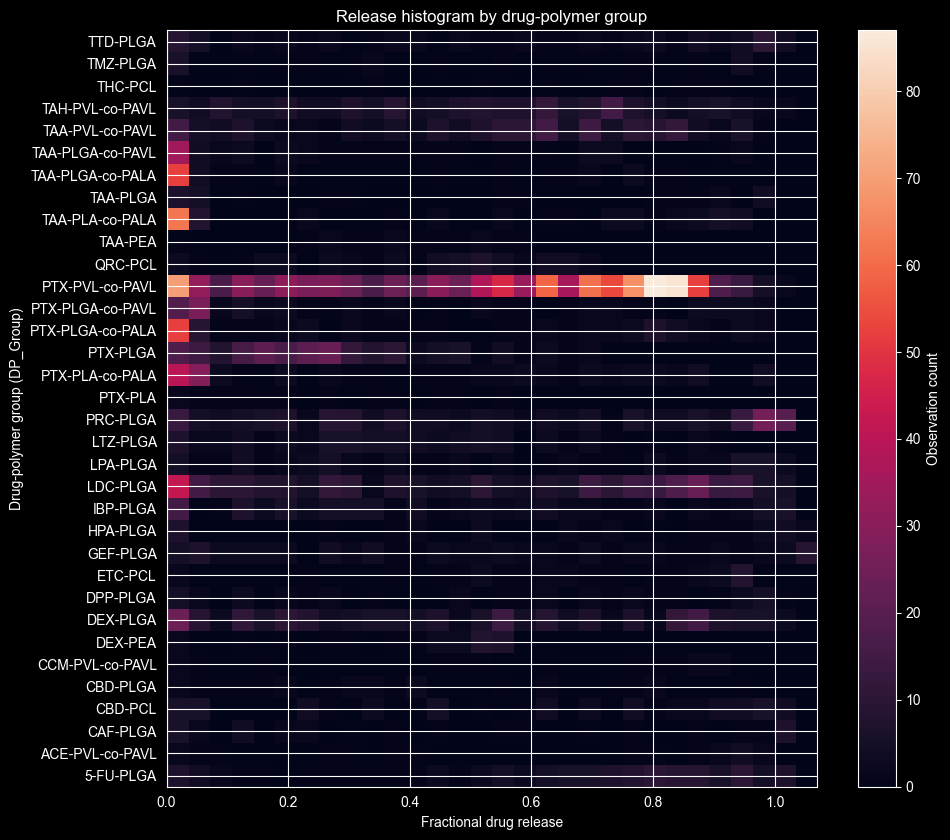

Saved 34 release histograms to lai_outputs/release_histograms_by_dp_group


In [161]:
# Release histograms by drug-polymer group
GROUP_COL = "DP_Group"
group_order = sorted(df[GROUP_COL].dropna().unique())
group_positions = np.arange(1, len(group_order) + 1)
release_bins = np.linspace(df[TARGET].min(), df[TARGET].max(), 31)
release_hist_dir = os.path.join(OUTPUT_DIR, "release_histograms_by_dp_group")
os.makedirs(release_hist_dir, exist_ok=True)

for group in group_order:
    group_df = df.loc[df[GROUP_COL].eq(group)]
    safe_group = str(group).replace("/", "_").replace(" ", "_").replace("=", "")

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(group_df[TARGET].dropna(), bins=release_bins, alpha=0.85)
    ax.set_xlabel("Fractional drug release")
    ax.set_ylabel("Observation count")
    ax.set_title(f"Release histogram: {group}")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(
        os.path.join(release_hist_dir, f"release_{safe_group}_histogram.png"),
        dpi=300,
    )
    plt.close(fig)

# Overview: binned release counts per group, with group on the y-axis.
release_hist = np.vstack([
    np.histogram(
        df.loc[df[GROUP_COL].eq(group), TARGET].dropna(),
        bins=release_bins,
    )[0]
    for group in group_order
])

fig, ax = plt.subplots(figsize=(10, max(8, 0.25 * len(group_order))))
image = ax.imshow(
    release_hist,
    aspect="auto",
    origin="lower",
    interpolation="nearest",
    extent=[release_bins[0], release_bins[-1], 0.5, len(group_order) + 0.5],
)

ax.set_yticks(group_positions)
ax.set_yticklabels(group_order)
ax.set_xlabel("Fractional drug release")
ax.set_ylabel("Drug-polymer group (DP_Group)")
ax.set_title("Release histogram by drug-polymer group")
plt.colorbar(image, ax=ax, label="Observation count")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "release_histogram_by_dp_group_overview.png"), dpi=300)
plt.show()

print(f"Saved {len(group_order)} release histograms to {release_hist_dir}")

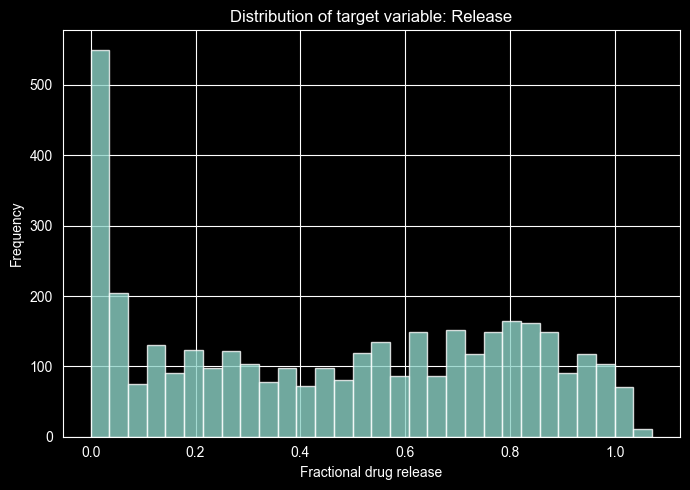

In [162]:
plt.figure(figsize=(7, 5))
plt.hist(df[TARGET], bins=30, alpha=0.8)
plt.xlabel("Fractional drug release")
plt.ylabel("Frequency")
plt.title("Distribution of target variable: Release")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "target_distribution.png"), dpi=300)
plt.show()

In [163]:
# Separate Release histograms by group and by individual release profile
GROUP_COL = "DP_Group"
PROFILE_COL = "Experimental_index"
SHOW_PLOTS = False  # Set to True if you want every histogram displayed in the notebook.

def safe_filename(value):
    return (
        str(value)
        .replace("/", "_")
        .replace(" ", "_")
        .replace("-", "_")
        .replace("=", "")
    )

release_bins = np.linspace(df[TARGET].min(), df[TARGET].max(), 31)

group_hist_dir = os.path.join(OUTPUT_DIR, "release_histograms_by_group")
profile_hist_root = os.path.join(OUTPUT_DIR, "release_histograms_by_group_profile")
os.makedirs(group_hist_dir, exist_ok=True)
os.makedirs(profile_hist_root, exist_ok=True)

# One separate histogram for each drug-polymer group.
for group, group_df in df.groupby(GROUP_COL, sort=True):
    safe_group = safe_filename(group)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(group_df[TARGET].dropna(), bins=release_bins, alpha=0.8)
    ax.set_xlabel("Fractional drug release")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of Release: {group}")
    fig.tight_layout()
    fig.savefig(
        os.path.join(group_hist_dir, f"release_{safe_group}_histogram.png"),
        dpi=300,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)

# One separate histogram for each individual profile inside each group.
profile_count = 0
for (group, profile_id), profile_df in df.groupby([GROUP_COL, PROFILE_COL], sort=True):
    safe_group = safe_filename(group)
    safe_profile = safe_filename(profile_id)
    profile_hist_dir = os.path.join(profile_hist_root, safe_group)
    os.makedirs(profile_hist_dir, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(profile_df[TARGET].dropna(), bins=release_bins, alpha=0.8)
    ax.set_xlabel("Fractional drug release")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Distribution of Release: {group}, profile {profile_id}")
    fig.tight_layout()
    fig.savefig(
        os.path.join(
            profile_hist_dir,
            f"release_{safe_group}_profile_{safe_profile}_histogram.png",
        ),
        dpi=300,
    )
    if SHOW_PLOTS:
        plt.show()
    plt.close(fig)
    profile_count += 1

print(f"Saved {df[GROUP_COL].nunique()} separate group histograms to {group_hist_dir}")
print(f"Saved {profile_count} separate group/profile histograms to {profile_hist_root}")


Saved 34 separate group histograms to lai_outputs/release_histograms_by_group
Saved 181 separate group/profile histograms to lai_outputs/release_histograms_by_group_profile


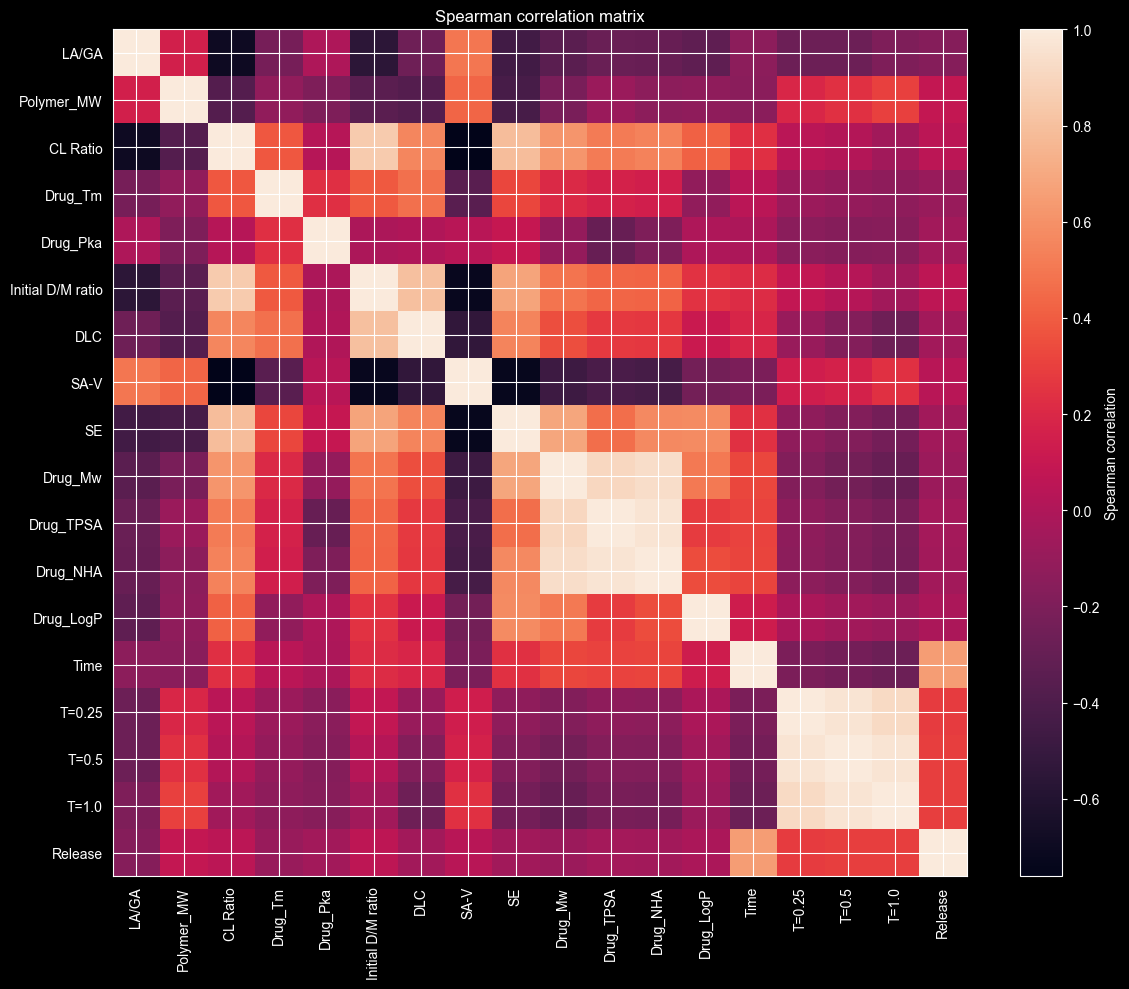

In [164]:
# Correlation matrix for numeric features and target
corr_cols = ALL_FEATURES + [TARGET]
corr = df[corr_cols].corr(method="spearman")

plt.figure(figsize=(12, 10))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.colorbar(label="Spearman correlation")
plt.title("Spearman correlation matrix")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "spearman_correlation_matrix.png"), dpi=300)
plt.show()

# Save correlation matrix
corr.to_csv(os.path.join(OUTPUT_DIR, "spearman_correlation_matrix.csv"))

### Paper comment: EDA

> Exploratory analysis was repeated in Python to make the workflow reproducible. Missing values, descriptive statistics, target distribution, and correlation structure were examined before model training. This step is important because several descriptors describe related physicochemical properties, so redundancy and multicollinearity are expected.

### Optional VIF analysis for the linear baseline

VIF is mainly useful for linear models.  
Tree-based models can handle correlated features better, but VIF is still useful as a connection to the Orange homework.

In [165]:
# Optional VIF function.
# statsmodels may not be installed in every environment, so install if needed.
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
except ImportError:
    import shutil
    import subprocess
    import sys
    if shutil.which("uv"):
        subprocess.check_call(["uv", "pip", "install", "--python", sys.executable, "-q", "statsmodels"])
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "statsmodels"])
    from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(dataframe, features):
    X_vif = dataframe[features].copy()
    X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

    # VIF requires numeric features and no constant duplicate problems.
    X_values = X_vif.values

    rows = []
    for i, col in enumerate(features):
        try:
            vif_value = variance_inflation_factor(X_values, i)
        except Exception:
            vif_value = np.nan
        rows.append({"Feature": col, "VIF": vif_value})

    return pd.DataFrame(rows).sort_values("VIF", ascending=False)

vif_table = calculate_vif(df, ALL_FEATURES)
display(vif_table)

vif_table.to_csv(os.path.join(OUTPUT_DIR, "vif_all_features.csv"), index=False)


,Feature,VIF
9,Drug_Mw,565.959213
11,Drug_NHA,402.248273
10,Drug_TPSA,400.199306
15,T=0.5,111.838240
16,T=1.0,50.646403
14,T=0.25,39.919470
12,Drug_LogP,33.268305
4,Drug_Pka,18.536084
3,Drug_Tm,18.340037
5,Initial D/M ratio,12.827757


In [166]:
def iterative_vif_selection(dataframe, features, threshold=5.0):
    selected = features.copy()
    history = []

    while True:
        vif_table = calculate_vif(dataframe, selected)
        max_vif = vif_table["VIF"].max()

        if pd.isna(max_vif) or max_vif <= threshold:
            break

        remove_feature = vif_table.iloc[0]["Feature"]
        history.append({
            "removed_feature": remove_feature,
            "max_vif": max_vif,
            "remaining_features": len(selected) - 1
        })
        selected.remove(remove_feature)

    final_vif = calculate_vif(dataframe, selected)
    return selected, pd.DataFrame(history), final_vif

vif_selected_features, vif_history, final_vif = iterative_vif_selection(df, ALL_FEATURES, threshold=5.0)

print("Selected features after iterative VIF:")
print(vif_selected_features)

display(vif_history)
display(final_vif)

vif_history.to_csv(os.path.join(OUTPUT_DIR, "vif_elimination_history.csv"), index=False)
final_vif.to_csv(os.path.join(OUTPUT_DIR, "vif_selected_features.csv"), index=False)

Selected features after iterative VIF:
['LA/GA', 'Polymer_MW', 'DLC', 'SA-V', 'Drug_TPSA', 'Drug_LogP', 'Time', 'T=0.25']


,removed_feature,max_vif,remaining_features
0,Drug_Mw,565.959213,16
1,Drug_NHA,344.736909,15
2,T=0.5,94.424485,14
3,T=1.0,17.697707,13
4,Drug_Tm,15.364699,12
5,Initial D/M ratio,12.183919,11
6,Drug_Pka,8.446216,10
7,CL Ratio,6.946450,9
8,SE,5.063465,8


,Feature,VIF
4,Drug_TPSA,4.031936
2,DLC,3.702584
5,Drug_LogP,3.376416
1,Polymer_MW,3.329146
7,T=0.25,1.936235
6,Time,1.925993
0,LA/GA,1.770712
3,SA-V,1.607809


### Paper comment: VIF

> VIF analysis was used only to support the interpretation of linear models. After iterative elimination of highly collinear predictors, a reduced feature set can be used for Ridge/MLR-style baselines. However, the main predictive models in this project are tree-based because the Orange homework already suggested that the release process is not purely linear.

### Profile-aware grouped validation

A random row split is not appropriate because time points from the same release profile are strongly related. The main validation strategy is `GroupKFold` with `Experimental_index`, ensuring that every profile appears entirely in either the training or test fold. `DP_Group` is reserved for optional stricter validation because it tests generalization to broader unseen drug-polymer groups.

In [167]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

def make_group_splits(X, y, group_values, n_splits=5):
    n_groups = pd.Series(group_values).nunique()
    if n_groups < n_splits:
        raise ValueError(f"Need at least {n_splits} groups for GroupKFold, but found {n_groups}.")
    splitter = GroupKFold(n_splits=n_splits)
    return splitter.split(X, y, group_values)

def evaluate_group_cv(model, X, y, group_values, n_splits=5, group_col=MAIN_GROUP_COL, source_df=None):
    '''
    Evaluates a regression model using GroupKFold.

    The default grouping column is Experimental_index. DP_Group should be used only
    for an optional stricter sensitivity analysis.
    '''
    if source_df is None:
        source_df = df.loc[X.index]

    group_values = pd.Series(group_values, index=X.index)
    fold_rows = []
    oof_pred = np.zeros(len(y), dtype=float)
    oof_fold = np.zeros(len(y), dtype=int)

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(X, y, group_values, n_splits=n_splits)):
        model_fold = clone(model)

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model_fold.fit(X_train, y_train)
        pred = np.ravel(model_fold.predict(X_test))

        oof_pred[test_idx] = pred
        oof_fold[test_idx] = fold

        metrics = regression_metrics(y_test, pred)
        metrics["fold"] = fold
        metrics["group_col"] = group_col
        metrics["n_test_rows"] = len(test_idx)
        metrics["n_test_groups"] = group_values.iloc[test_idx].nunique()
        fold_rows.append(metrics)

    fold_df = pd.DataFrame(fold_rows)
    summary = {
        "group_col": group_col,
        "MAE_mean": fold_df["MAE"].mean(),
        "MAE_std": fold_df["MAE"].std(),
        "RMSE_mean": fold_df["RMSE"].mean(),
        "RMSE_std": fold_df["RMSE"].std(),
        "R2_mean": fold_df["R2"].mean(),
        "R2_std": fold_df["R2"].std()
    }

    oof_df = pd.DataFrame({
        "y_true": y.values,
        "y_pred": oof_pred,
        "fold": oof_fold,
        "group_col": group_col,
        "Experimental_index": source_df["Experimental_index"].values,
        "DP_Group": source_df["DP_Group"].values,
        "Time": source_df["Time"].values
    })

    return fold_df, summary, oof_df

### Paper-ready validation statement

Model performance was evaluated using profile-aware `GroupKFold` cross-validation. The primary grouping variable was `Experimental_index`, so all measurements from a release profile were assigned to the same fold. This avoids overly optimistic performance estimates caused by training on some time points from a profile and testing on other time points from the same profile. Validation by `DP_Group` is included only as a stricter optional sensitivity analysis.

## 4. Baseline model comparison: Ridge, PLS, RF, GB, XGBoost, LightGBM, CatBoost

The Orange baseline is repeated and extended in Python using grouped validation. Linear models (Ridge and PLS) provide interpretable low-complexity references, while tree-based ensembles test nonlinear relationships among polymer, drug, formulation, and time variables. CatBoost is included as an additional gradient-boosted tree model and is compared directly with LightGBM for the downstream workflow.

In [168]:
def make_lgbm_regressor(n_estimators=700, learning_rate=0.025):
    return LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=31,
        min_child_samples=10,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        verbose=-1
    )

def make_catboost_regressor(iterations=700, learning_rate=0.025):
    return CatBoostRegressor(
        iterations=iterations,
        learning_rate=learning_rate,
        depth=6,
        loss_function="RMSE",
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
        thread_count=-1
    )

def make_direct_tree_model(model_name):
    if model_name == "CatBoost":
        return make_catboost_regressor(iterations=700, learning_rate=0.025)
    if model_name == "LightGBM":
        return make_lgbm_regressor(n_estimators=700, learning_rate=0.025)
    raise ValueError(f"Unsupported direct model: {model_name}")

models = {
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "PLS": make_pipeline(StandardScaler(), PLSRegression(n_components=5)),
    "Random Forest": RandomForestRegressor(
        n_estimators=400,
        random_state=RANDOM_STATE,
        min_samples_leaf=2,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "LightGBM": make_lgbm_regressor(n_estimators=500, learning_rate=0.03),
    "CatBoost": make_catboost_regressor(iterations=500, learning_rate=0.03)
}

X_all = df[ALL_FEATURES]
y = df[TARGET]

baseline_rows = []
baseline_oof = {}

for name, model in models.items():
    print(f"Evaluating: {name}")
    fold_df, summary, oof_df = evaluate_group_cv(model, X_all, y, groups, n_splits=5)
    row = {"model": name, **summary}
    baseline_rows.append(row)
    baseline_oof[name] = oof_df

baseline_results = pd.DataFrame(baseline_rows).sort_values("MAE_mean")
display(baseline_results)

candidate_direct_results = baseline_results[
    baseline_results["model"].isin(["LightGBM", "CatBoost"])
].copy()
selected_direct_model_name = candidate_direct_results.sort_values("MAE_mean").iloc[0]["model"]
selected_direct_model_mae = candidate_direct_results.sort_values("MAE_mean").iloc[0]["MAE_mean"]

print("Direct model selected for sections 5 onward:", selected_direct_model_name)
print("Selection rule: lower grouped-CV MAE_mean between LightGBM and CatBoost.")
display(candidate_direct_results)

baseline_results.to_csv(os.path.join(OUTPUT_DIR, "baseline_groupcv_results.csv"), index=False)
candidate_direct_results.to_csv(os.path.join(OUTPUT_DIR, "lightgbm_vs_catboost_groupcv_results.csv"), index=False)

Evaluating: Ridge
Evaluating: PLS
Evaluating: Random Forest
Evaluating: Gradient Boosting
Evaluating: XGBoost
Evaluating: LightGBM
Evaluating: CatBoost


,model,group_col,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
5,LightGBM,Experimental_index,0.068334,0.002215,0.102908,0.007231,0.901258,0.013423
2,Random Forest,Experimental_index,0.068927,0.004928,0.106075,0.013747,0.894348,0.025611
6,CatBoost,Experimental_index,0.074936,0.003439,0.107108,0.006091,0.893211,0.011413
4,XGBoost,Experimental_index,0.085904,0.008268,0.117580,0.010577,0.869662,0.032344
3,Gradient Boosting,Experimental_index,0.089919,0.004359,0.122873,0.005696,0.858785,0.021168
0,Ridge,Experimental_index,0.197757,0.014758,0.241499,0.015624,0.458120,0.049181
1,PLS,Experimental_index,0.205782,0.013508,0.249704,0.012826,0.420816,0.040390


Direct model selected for sections 5 onward: LightGBM
Selection rule: lower grouped-CV MAE_mean between LightGBM and CatBoost.


,model,group_col,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
5,LightGBM,Experimental_index,0.068334,0.002215,0.102908,0.007231,0.901258,0.013423
6,CatBoost,Experimental_index,0.074936,0.003439,0.107108,0.006091,0.893211,0.011413


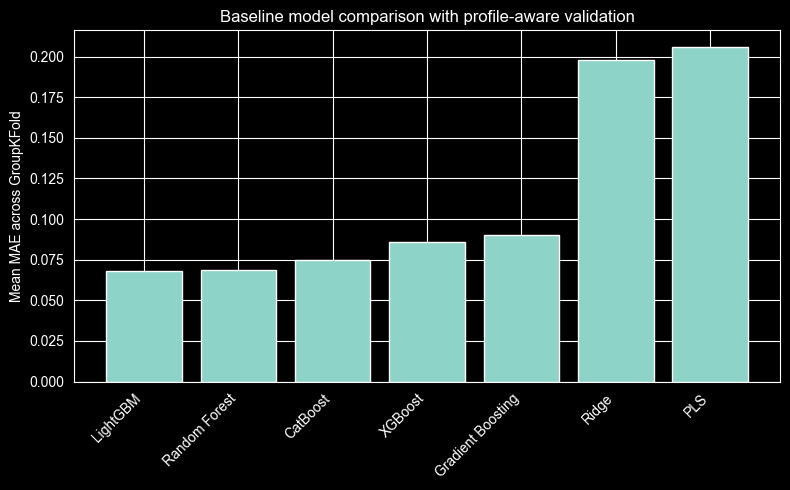

In [169]:
plt.figure(figsize=(8, 5))
plt.bar(baseline_results["model"], baseline_results["MAE_mean"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Mean MAE across GroupKFold")
plt.title("Baseline model comparison with profile-aware validation")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "baseline_model_comparison_mae.png"), dpi=300)
plt.show()

### Paper-ready baseline model comparison

The preliminary Orange model comparison was repeated in Python with profile-aware grouped validation. CatBoost was added to the model set and compared directly with LightGBM. From section 5 onward, the notebook automatically uses whichever of CatBoost or LightGBM has the lower grouped-validation `MAE_mean` in the baseline comparison.

## 5. Zero-shot vs few-shot prediction

This comparison separates two practically different use cases. Zero-shot prediction estimates the full release profile from pre-experimental descriptors only. Few-shot prediction includes early release measurements and therefore tests whether limited early experimental data improves prediction of later release behavior. The model used here is selected from the section 4 LightGBM-versus-CatBoost grouped-CV comparison.

In [170]:
zero_model = make_direct_tree_model(selected_direct_model_name)
few_model = make_direct_tree_model(selected_direct_model_name)

X_zero = df[ZERO_SHOT_FEATURES]
X_few = df[FEW_SHOT_FEATURES]

print(f"Using {selected_direct_model_name} for zero-shot and few-shot prediction.")

zero_fold_df, zero_summary, zero_oof = evaluate_group_cv(
    zero_model, X_zero, y, groups, n_splits=5
)

few_fold_df, few_summary, few_oof = evaluate_group_cv(
    few_model, X_few, y, groups, n_splits=5
)

zero_few_results = pd.DataFrame([
    {"scenario": "Zero-shot", "model": selected_direct_model_name, **zero_summary},
    {"scenario": "Few-shot", "model": selected_direct_model_name, **few_summary}
]).sort_values("MAE_mean")

display(zero_few_results)

zero_few_results.to_csv(os.path.join(OUTPUT_DIR, "zero_vs_few_shot_results.csv"), index=False)
zero_oof.to_csv(os.path.join(OUTPUT_DIR, "zero_shot_oof_predictions.csv"), index=False)
few_oof.to_csv(os.path.join(OUTPUT_DIR, "few_shot_oof_predictions.csv"), index=False)

Using LightGBM for zero-shot and few-shot prediction.


,scenario,model,group_col,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
1,Few-shot,LightGBM,Experimental_index,0.068674,0.002147,0.103463,0.006623,0.900263,0.012331
0,Zero-shot,LightGBM,Experimental_index,0.082755,0.004583,0.118666,0.005327,0.868907,0.012831


### Optional stricter validation by `DP_Group`

The primary paper results should use `Experimental_index` grouping. If the goal is to test generalization to entirely unseen drug-polymer groups, set `RUN_STRICT_DP_GROUP_VALIDATION = True` above and rerun the notebook.

In [171]:
if RUN_STRICT_DP_GROUP_VALIDATION:
    strict_groups = df[STRICT_GROUP_COL]

    strict_zero_fold_df, strict_zero_summary, strict_zero_oof = evaluate_group_cv(
        zero_model,
        X_zero,
        y,
        strict_groups,
        n_splits=5,
        group_col=STRICT_GROUP_COL
    )

    strict_few_fold_df, strict_few_summary, strict_few_oof = evaluate_group_cv(
        few_model,
        X_few,
        y,
        strict_groups,
        n_splits=5,
        group_col=STRICT_GROUP_COL
    )

    strict_zero_few_results = pd.DataFrame([
        {"scenario": "Zero-shot, DP_Group strict", **strict_zero_summary},
        {"scenario": "Few-shot, DP_Group strict", **strict_few_summary}
    ]).sort_values("MAE_mean")

    display(strict_zero_few_results)
    strict_zero_few_results.to_csv(os.path.join(OUTPUT_DIR, "zero_vs_few_shot_results_dp_group.csv"), index=False)
    strict_zero_oof.to_csv(os.path.join(OUTPUT_DIR, "zero_shot_oof_predictions_dp_group.csv"), index=False)
    strict_few_oof.to_csv(os.path.join(OUTPUT_DIR, "few_shot_oof_predictions_dp_group.csv"), index=False)
else:
    print("Strict DP_Group validation skipped. Set RUN_STRICT_DP_GROUP_VALIDATION = True to enable it.")

Strict DP_Group validation skipped. Set RUN_STRICT_DP_GROUP_VALIDATION = True to enable it.


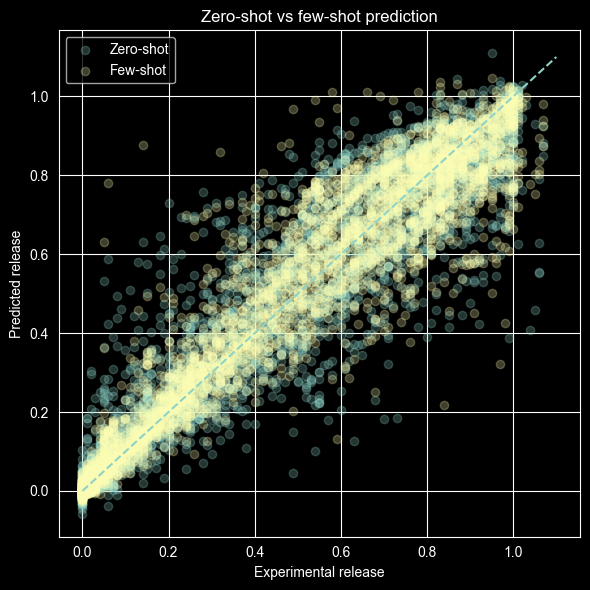

In [172]:
plt.figure(figsize=(6, 6))
plt.scatter(zero_oof["y_true"], zero_oof["y_pred"], alpha=0.25, label="Zero-shot")
plt.scatter(few_oof["y_true"], few_oof["y_pred"], alpha=0.25, label="Few-shot")
plt.plot([0, 1.1], [0, 1.1], linestyle="--")
plt.xlabel("Experimental release")
plt.ylabel("Predicted release")
plt.title("Zero-shot vs few-shot prediction")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "zero_vs_few_predicted_vs_true.png"), dpi=300)
plt.show()

### Paper-ready zero-shot vs few-shot result

The zero-shot and few-shot models were evaluated with the same `Experimental_index` grouped folds. The estimator was selected by comparing CatBoost and LightGBM in the grouped baseline model comparison. Improvement in the few-shot setting indicates that early release values contain useful information about burst release and downstream kinetic behavior that is not fully captured by static formulation descriptors alone.

## 6. Full release profile prediction by varying only Time

A final direct tree model is trained on all rows after cross-validation has estimated generalization performance. If CatBoost outperforms LightGBM in the section 4 grouped comparison, CatBoost is used here; otherwise LightGBM is used. For profile visualization, formulation and drug descriptors are fixed for one `Experimental_index`, and only `Time` is varied over a continuous grid.

In [173]:
best_direct_model = make_direct_tree_model(selected_direct_model_name)
best_direct_model.fit(X_few, y)

print(f"Final direct model trained on all few-shot rows: {selected_direct_model_name}")

Final direct model trained on all few-shot rows: LightGBM


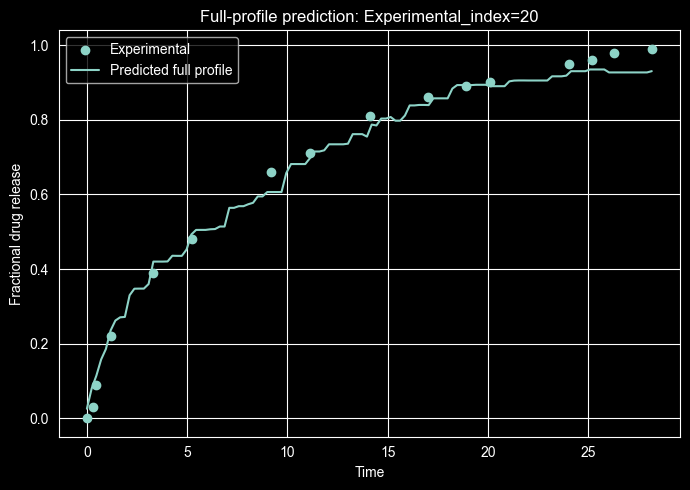

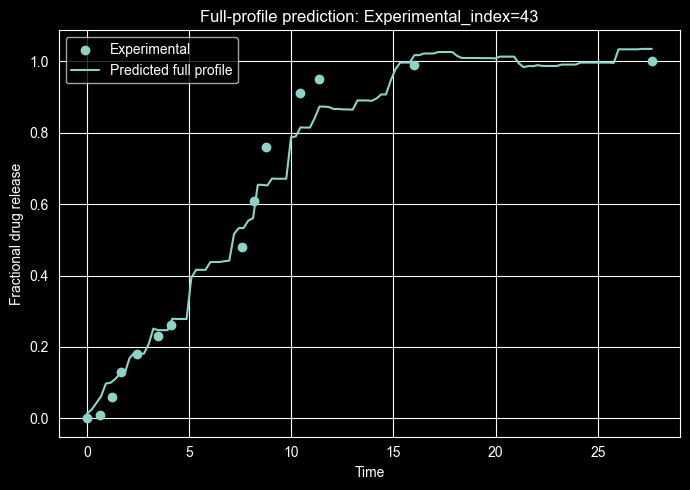

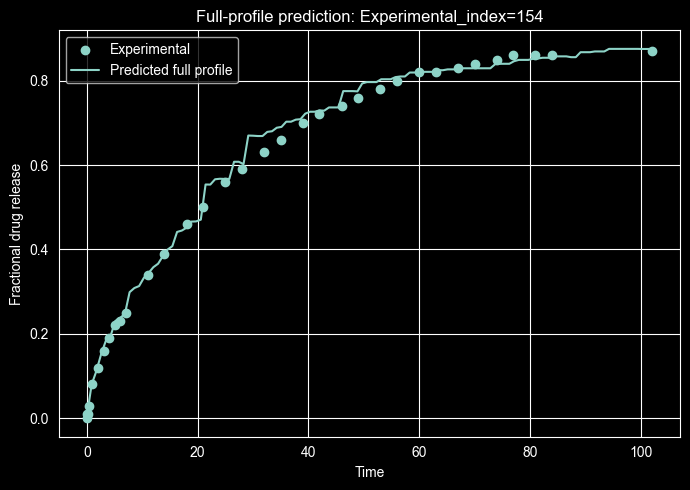

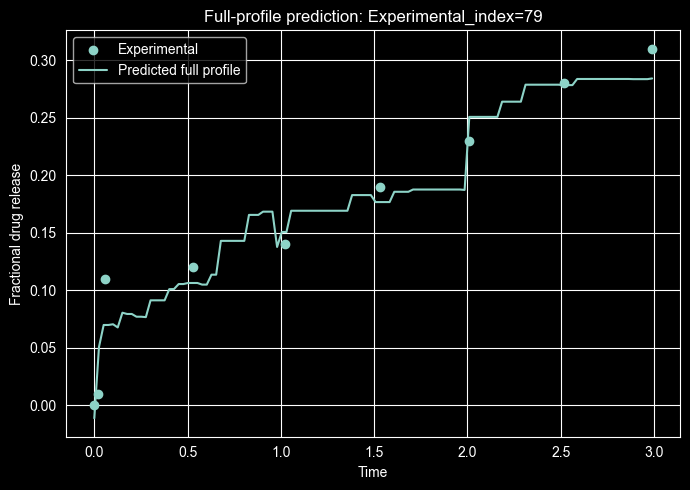

In [174]:
def predict_release_profile(model, data, profile_id, features, n_points=120, use_observed_time_range=True):
    '''
    Predicts a continuous release profile by:
    - selecting one formulation,
    - keeping formulation/drug descriptors fixed,
    - varying only Time over a grid.
    '''
    profile = data[data["Experimental_index"] == profile_id].sort_values("Time").copy()
    if profile.empty:
        raise ValueError(f"Profile ID {profile_id} not found.")

    base_row = profile.iloc[0].copy()

    if use_observed_time_range:
        t_min = profile["Time"].min()
        t_max = profile["Time"].max()
    else:
        t_min = 0
        t_max = data["Time"].max()

    time_grid = np.linspace(t_min, t_max, n_points)

    X_grid = pd.DataFrame([base_row[features].to_dict()] * n_points)
    X_grid["Time"] = time_grid

    pred = np.ravel(model.predict(X_grid[features]))

    return profile, time_grid, pred

# Choose a few example profiles for plotting.
example_profiles = df["Experimental_index"].drop_duplicates().sample(
    min(4, df["Experimental_index"].nunique()),
    random_state=RANDOM_STATE
).tolist()

for profile_id in example_profiles:
    profile, time_grid, pred = predict_release_profile(
        best_direct_model,
        df,
        profile_id,
        FEW_SHOT_FEATURES
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")
    plt.plot(time_grid, pred, label="Predicted full profile")
    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Full-profile prediction: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"profile_prediction_{profile_id}.png"), dpi=300)
    plt.show()

### Paper-ready full-profile prediction

The selected direct model can be used as a continuous release-profile predictor by holding formulation descriptors constant and varying only `Time`. This produces a smooth predicted trajectory that can be plotted against the experimental time points for a selected formulation.

## 7. SHAP explainability

SHAP values are used to interpret the final selected tree model. If CatBoost outperforms LightGBM in grouped validation, SHAP is computed for CatBoost; otherwise SHAP is computed for LightGBM. The global beeswarm plot summarizes the strongest predictors, while feature-specific dependence plots support mechanistic interpretation of `Time`, polymer descriptors, drug descriptors, and early release measurements.

Running SHAP for selected model: LightGBM


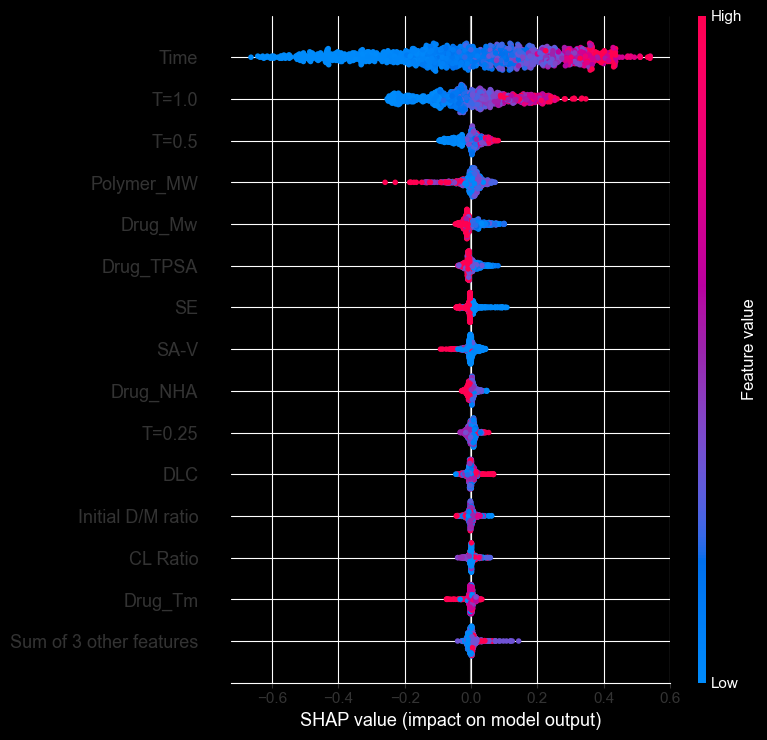

,feature,mean_abs_shap,model
13,Time,0.217024,LightGBM
16,T=1.0,0.100825,LightGBM
15,T=0.5,0.027200,LightGBM
1,Polymer_MW,0.021167,LightGBM
9,Drug_Mw,0.020274,LightGBM
10,Drug_TPSA,0.013204,LightGBM
8,SE,0.012561,LightGBM
7,SA-V,0.010179,LightGBM
11,Drug_NHA,0.007994,LightGBM
14,T=0.25,0.007866,LightGBM


In [175]:
import shap

# Use a sample for faster SHAP computation.
X_shap = X_few.sample(min(1200, len(X_few)), random_state=RANDOM_STATE)

print(f"Running SHAP for selected model: {selected_direct_model_name}")
explainer = shap.TreeExplainer(best_direct_model)
shap_values = explainer(X_shap)

# Beeswarm plot
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_beeswarm.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save mean absolute SHAP importance
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values.values).mean(axis=0),
    "model": selected_direct_model_name
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance)
shap_importance.to_csv(os.path.join(OUTPUT_DIR, "shap_feature_importance.csv"), index=False)

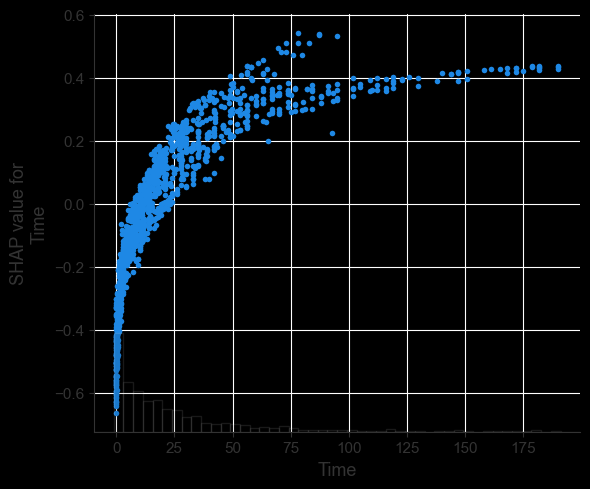

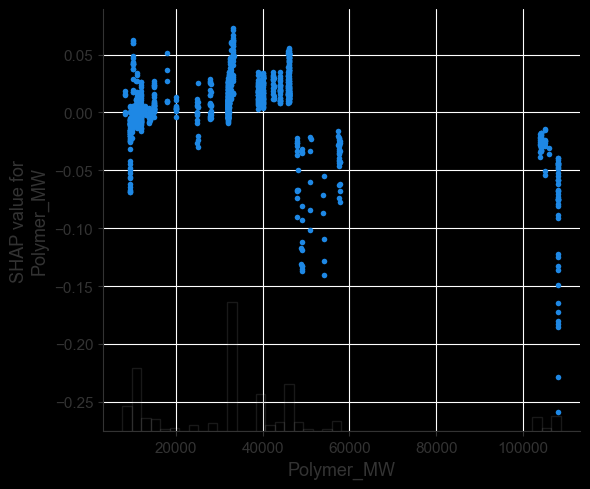

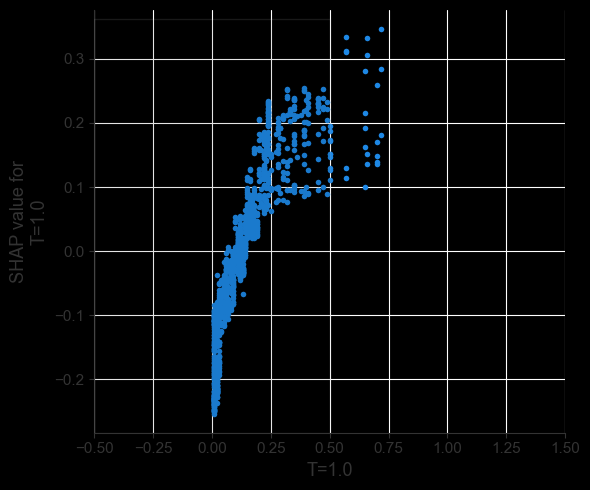

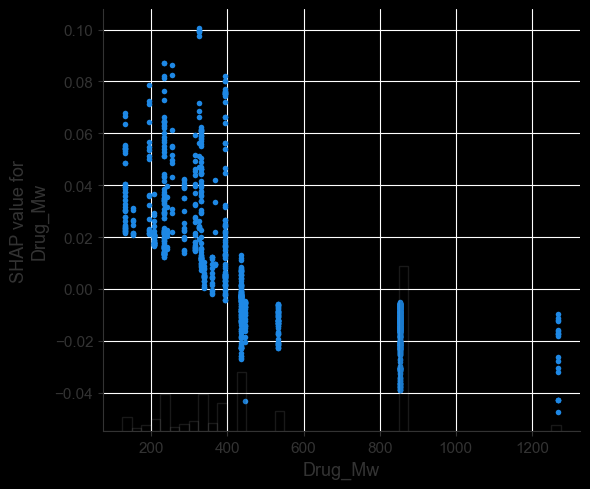

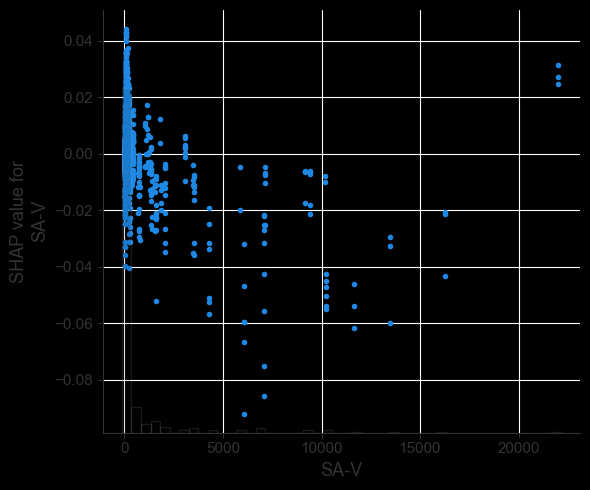

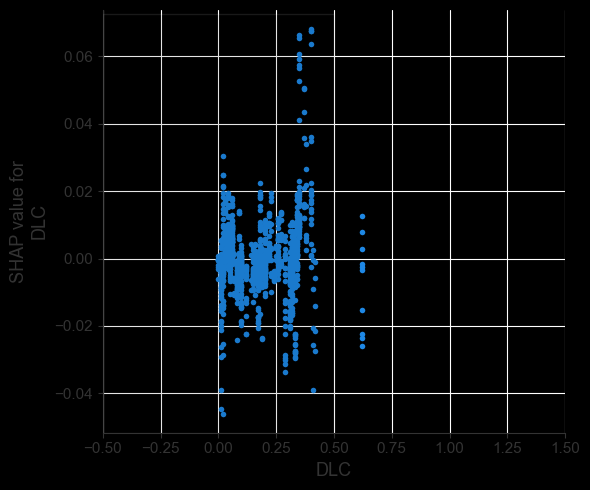

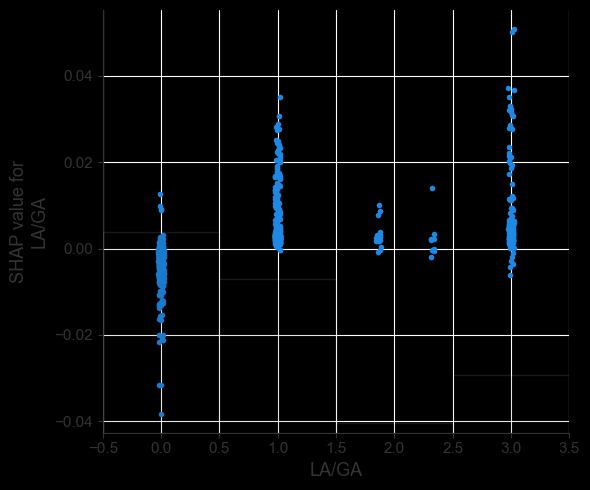

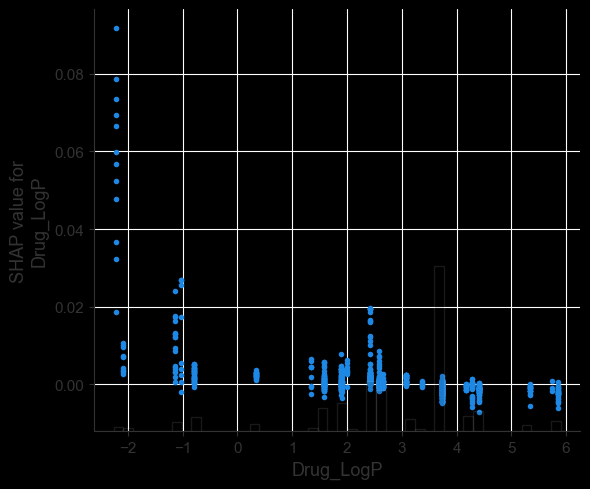

In [176]:
# Dependence/scatter plots for selected features
for feature in ["Time", "Polymer_MW", "T=1.0", "Drug_Mw", "SA-V", "DLC", "LA/GA", "Drug_LogP"]:
    if feature in X_shap.columns:
        shap.plots.scatter(shap_values[:, feature], show=False)
        plt.tight_layout()
        safe_name = feature.replace("/", "_").replace("=", "").replace(" ", "_")
        plt.savefig(os.path.join(OUTPUT_DIR, f"shap_scatter_{safe_name}.png"), dpi=300, bbox_inches="tight")
        plt.show()

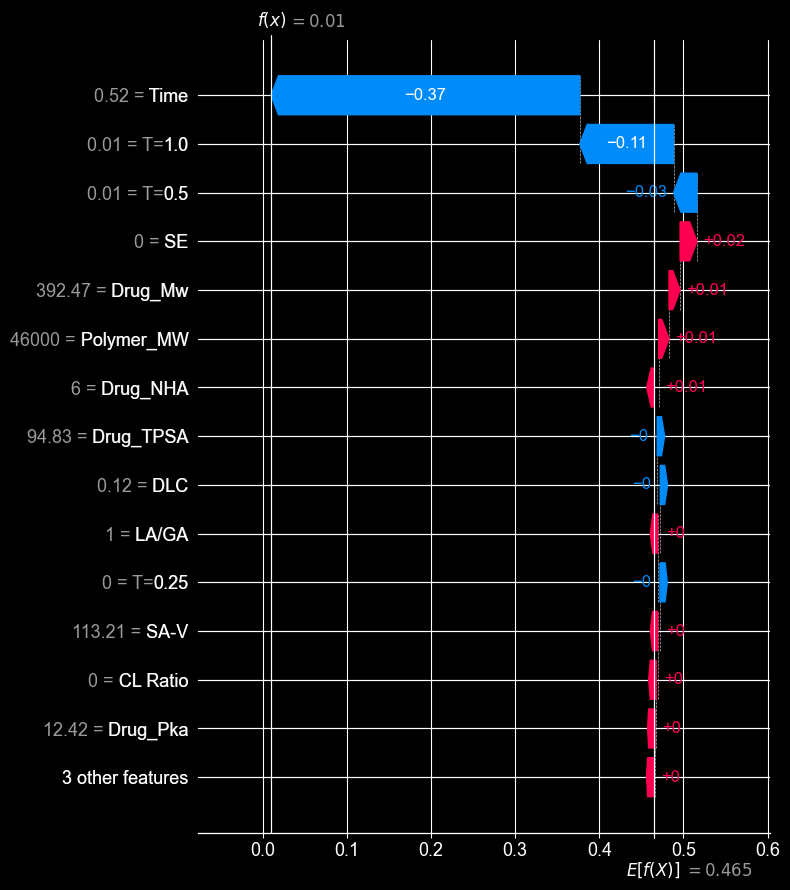

In [177]:
# Waterfall plot for one prediction
example_index = 0
shap.plots.waterfall(shap_values[example_index], max_display=15, show=False)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_waterfall_example.png"), dpi=300, bbox_inches="tight")
plt.show()

### Paper-ready SHAP interpretation

SHAP analysis was performed on the selected direct tree model: CatBoost if it outperformed LightGBM under grouped validation, otherwise LightGBM. The interpretation connects predictive performance with formulation science, including release time, early burst, polymer molecular weight, surface-area-to-volume ratio, drug loading, lactide/glycolide composition, molecular size, and lipophilicity.

## 8. Hybrid kinetic ML with Weibull/logistic curve fitting and parameter prediction

The hybrid approach first fits empirical kinetic curves to each observed release profile. The fitted Weibull parameters (`Fmax`, `tau`, `beta`) are then predicted from formulation descriptors, allowing a full release curve to be reconstructed from predicted kinetic parameters.

In [178]:
def weibull(t, fmax, tau, beta):
    t = np.asarray(t, dtype=float)
    return fmax * (1 - np.exp(-((np.maximum(t, 0) / tau) ** beta)))

def logistic4(t, y0, fmax, k, tmid):
    t = np.asarray(t, dtype=float)
    return y0 + (fmax - y0) / (1 + np.exp(-k * (t - tmid)))

def aic_score(y_true, y_pred, n_params):
    residuals = np.asarray(y_true) - np.asarray(y_pred)
    rss = np.sum(residuals ** 2)
    n = len(y_true)
    rss = max(rss, 1e-12)
    return n * np.log(rss / n) + 2 * n_params

def fit_weibull_profile(profile):
    profile = profile.sort_values("Time")
    t = profile["Time"].values.astype(float)
    y_obs = np.clip(profile["Release"].values.astype(float), 0, 1.2)

    if len(np.unique(t)) < 4:
        return None

    t_nonzero = t[t > 0]
    tau_start = np.median(t_nonzero) if len(t_nonzero) > 0 else 1.0

    p0 = [min(1.1, max(y_obs) + 0.05), max(tau_start, 0.1), 1.0]
    bounds = ([0.0, 0.01, 0.05], [1.2, 1000.0, 10.0])

    try:
        popt, _ = curve_fit(
            weibull, t, y_obs, p0=p0, bounds=bounds, maxfev=30000
        )
        y_fit = weibull(t, *popt)
        return {
            "Fmax": popt[0],
            "tau": popt[1],
            "beta": popt[2],
            "weibull_RMSE": np.sqrt(mean_squared_error(y_obs, y_fit)),
            "weibull_AIC": aic_score(y_obs, y_fit, n_params=3)
        }
    except Exception:
        return None

def fit_logistic_profile(profile):
    profile = profile.sort_values("Time")
    t = profile["Time"].values.astype(float)
    y_obs = np.clip(profile["Release"].values.astype(float), 0, 1.2)

    if len(np.unique(t)) < 4:
        return None

    p0 = [max(0.0, min(y_obs)), min(1.1, max(y_obs) + 0.05), 0.1, np.median(t)]
    bounds = ([0.0, 0.0, 0.001, 0.0], [0.6, 1.2, 10.0, 1000.0])

    try:
        popt, _ = curve_fit(
            logistic4, t, y_obs, p0=p0, bounds=bounds, maxfev=30000
        )
        y_fit = logistic4(t, *popt)
        return {
            "log_y0": popt[0],
            "log_Fmax": popt[1],
            "log_k": popt[2],
            "log_tmid": popt[3],
            "logistic_RMSE": np.sqrt(mean_squared_error(y_obs, y_fit)),
            "logistic_AIC": aic_score(y_obs, y_fit, n_params=4)
        }
    except Exception:
        return None

In [179]:
kinetic_rows = []

for profile_id, g in df.groupby("Experimental_index"):
    weib = fit_weibull_profile(g)
    logi = fit_logistic_profile(g)

    row = {
        "Experimental_index": profile_id,
        "DP_Group": g["DP_Group"].iloc[0],
        "n_points": len(g)
    }

    if weib is not None:
        row.update(weib)

    if logi is not None:
        row.update(logi)

    kinetic_rows.append(row)

kinetic_df = pd.DataFrame(kinetic_rows)

# Decide which empirical curve fit was better for each profile, when both are available.
kinetic_df["best_curve_by_AIC"] = np.where(
    kinetic_df["weibull_AIC"] <= kinetic_df["logistic_AIC"],
    "Weibull",
    "Logistic"
)

display(kinetic_df.head())
display(kinetic_df[["weibull_RMSE", "logistic_RMSE", "best_curve_by_AIC"]].describe())
display(kinetic_df["best_curve_by_AIC"].value_counts(dropna=False))

kinetic_df.to_csv(os.path.join(OUTPUT_DIR, "kinetic_curve_fit_parameters.csv"), index=False)

,Experimental_index,DP_Group,n_points,Fmax,tau,beta,weibull_RMSE,weibull_AIC,log_y0,log_Fmax,log_k,log_tmid,logistic_RMSE,logistic_AIC,best_curve_by_AIC
0,1,DEX-PEA,29,0.568925,12.749404,0.618787,0.004433,-308.287201,2.943002e-32,0.519962,0.159328,8.973645,0.034526,-187.230082,Weibull
1,2,GEF-PLGA,18,1.200000,48.617610,0.481211,0.039125,-110.676158,5.310597e-30,0.862870,0.075771,14.349361,0.077661,-83.994639,Weibull
2,3,GEF-PLGA,8,1.030508,0.843538,1.069839,0.042068,-44.695315,5.724353e-20,0.998303,2.953395,0.646045,0.070783,-34.370273,Weibull
3,4,GEF-PLGA,19,1.072381,2.969445,0.811659,0.027058,-131.170996,7.278120e-30,1.045964,0.635324,2.285517,0.068908,-93.649471,Weibull
4,5,GEF-PLGA,17,1.200000,56.991874,1.272517,0.031936,-111.096841,2.633548e-29,1.035068,0.062559,39.488626,0.041698,-100.028491,Weibull


,weibull_RMSE,logistic_RMSE
count,181.000000,181.000000
mean,0.029172,0.049330
std,0.020676,0.021648
min,0.003651,0.003651
25%,0.016091,0.031916
50%,0.022394,0.050938
75%,0.036136,0.062440
max,0.115045,0.109968


best_curve_by_AIC
Weibull     136
Logistic     45
Name: count, dtype: int64

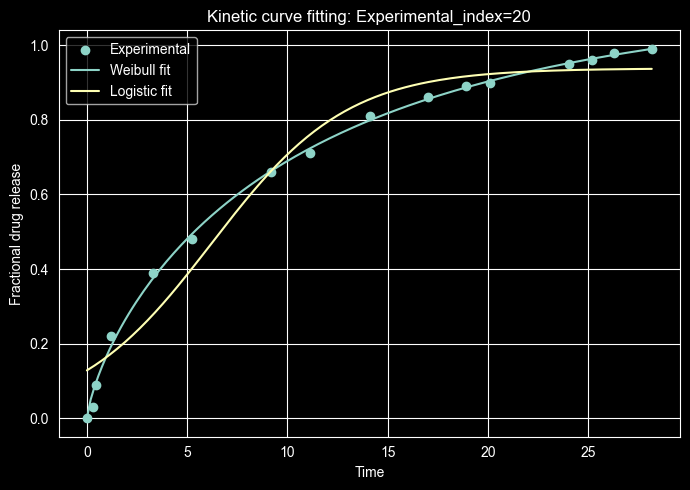

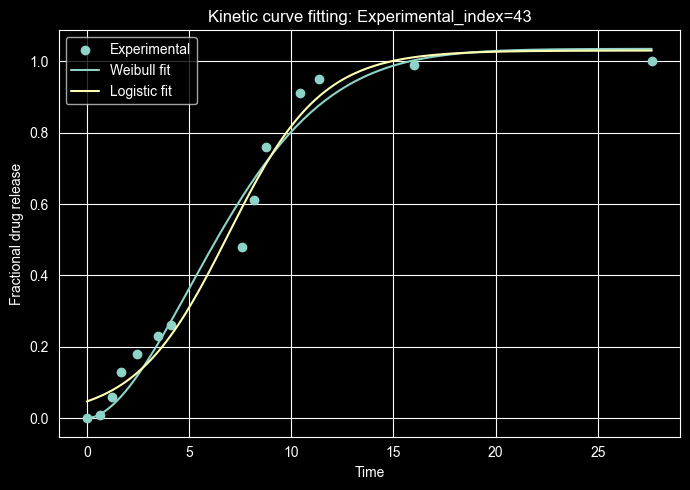

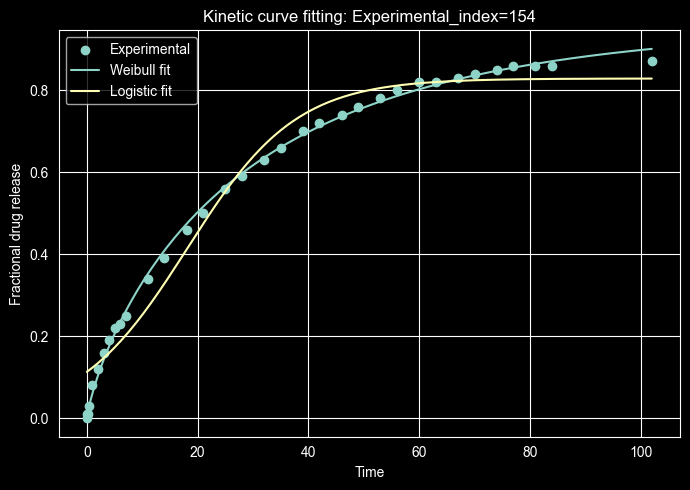

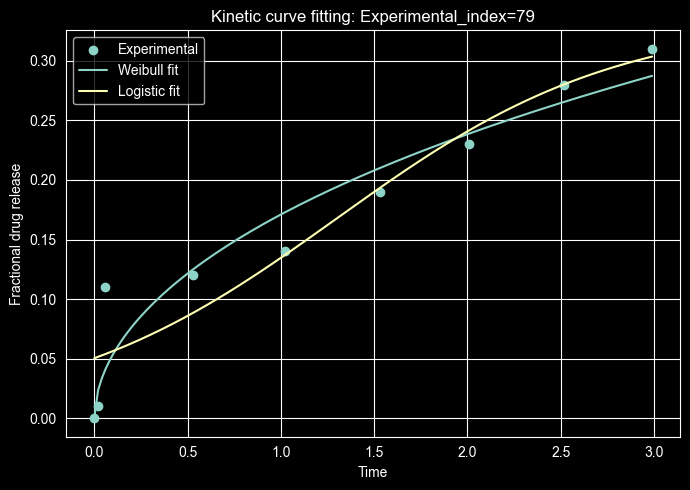

In [180]:
# Visualize fitted Weibull and Logistic curves for a few profiles.
fit_examples = kinetic_df["Experimental_index"].dropna().sample(
    min(4, len(kinetic_df)),
    random_state=RANDOM_STATE
).tolist()

for profile_id in fit_examples:
    profile = df[df["Experimental_index"] == profile_id].sort_values("Time")
    row = kinetic_df[kinetic_df["Experimental_index"] == profile_id].iloc[0]
    t_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), 150)

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")

    if not pd.isna(row.get("Fmax", np.nan)):
        y_weib = weibull(t_grid, row["Fmax"], row["tau"], row["beta"])
        plt.plot(t_grid, y_weib, label="Weibull fit")

    if not pd.isna(row.get("log_Fmax", np.nan)):
        y_log = logistic4(t_grid, row["log_y0"], row["log_Fmax"], row["log_k"], row["log_tmid"])
        plt.plot(t_grid, y_log, label="Logistic fit")

    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Kinetic curve fitting: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"kinetic_fit_{profile_id}.png"), dpi=300)
    plt.show()

### Paper comment: Kinetic curve fitting

> Each experimental release profile was fitted with empirical kinetic equations. The Weibull model was used as the main curve representation because it can describe different release shapes using only three parameters. Logistic fitting was included as a comparison for sigmoidal profiles. The fitted parameters summarize the entire release curve into interpretable kinetic descriptors.

### Predict Weibull kinetic parameters from formulation descriptors

This section creates one row per release profile and trains a multi-output model to predict `Fmax`, `tau`, and `beta`. The default grouped validation remains `Experimental_index`; optional `DP_Group` validation is available as a stricter sensitivity analysis.

In [181]:
# One row per profile with formulation descriptors.
# We take the first row because formulation descriptors are constant within a profile.
profile_features_df = (
    df.groupby("Experimental_index")
      .first()
      .reset_index()
)

# Features for kinetic parameter prediction.
# Remove Time because the kinetic parameters already describe the whole time profile.
FORMULATION_FEATURES_FEW = [c for c in FEW_SHOT_FEATURES if c != "Time"]
FORMULATION_FEATURES_ZERO = [c for c in ZERO_SHOT_FEATURES if c != "Time"]

profile_param_df = kinetic_df.merge(
    profile_features_df[["Experimental_index", "DP_Group"] + FORMULATION_FEATURES_FEW],
    on=["Experimental_index", "DP_Group"],
    how="left"
)

# Keep only profiles with successful Weibull fit.
profile_param_df = profile_param_df.dropna(subset=["Fmax", "tau", "beta"]).reset_index(drop=True)

display(profile_param_df.head())
print("Number of profiles with successful Weibull fit:", len(profile_param_df))

,Experimental_index,DP_Group,n_points,Fmax,tau,beta,weibull_RMSE,weibull_AIC,log_y0,log_Fmax,log_k,log_tmid,logistic_RMSE,logistic_AIC,best_curve_by_AIC,LA/GA,Polymer_MW,CL Ratio,Drug_Tm,Drug_Pka,Initial D/M ratio,DLC,SA-V,SE,Drug_Mw,Drug_TPSA,Drug_NHA,Drug_LogP,T=0.25,T=0.5,T=1.0
0,1,DEX-PEA,29,0.568925,12.749404,0.618787,0.004433,-308.287201,2.943002e-32,0.519962,0.159328,8.973645,0.034526,-187.230082,Weibull,0.0,49000.0,0.0,262.0,12.42,0.2,0.15,422.54,0.0,392.47,94.83,6.0,1.90,0.04,0.05,0.09
1,2,GEF-PLGA,18,1.200000,48.617610,0.481211,0.039125,-110.676158,5.310597e-30,0.862870,0.075771,14.349361,0.077661,-83.994639,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.07,101.69,1.0,446.91,68.74,9.0,4.28,0.05,0.10,0.19
2,3,GEF-PLGA,8,1.030508,0.843538,1.069839,0.042068,-44.695315,5.724353e-20,0.998303,2.953395,0.646045,0.070783,-34.370273,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.03,1200.00,1.0,446.91,68.74,9.0,4.28,0.25,0.45,0.72
3,4,GEF-PLGA,19,1.072381,2.969445,0.811659,0.027058,-131.170996,7.278120e-30,1.045964,0.635324,2.285517,0.068908,-93.649471,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.06,187.50,1.0,446.91,68.74,9.0,4.28,0.11,0.22,0.39
4,5,GEF-PLGA,17,1.200000,56.991874,1.272517,0.031936,-111.096841,2.633548e-29,1.035068,0.062559,39.488626,0.041698,-100.028491,Weibull,1.0,44000.0,0.0,213.0,16.11,0.1,0.08,85.71,1.0,446.91,68.74,9.0,4.28,0.02,0.02,0.03


Number of profiles with successful Weibull fit: 181


In [182]:
def sanitize_weibull_parameter_predictions(param_array, fallback_values):
    '''Replace invalid Weibull parameter predictions and clip to fitting bounds.'''
    arr = np.asarray(param_array, dtype=float)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    fallback = np.asarray(fallback_values, dtype=float)
    if fallback.ndim == 1:
        fallback = fallback.reshape(1, -1)

    arr = np.where(np.isfinite(arr), arr, fallback)
    arr[:, 0] = np.clip(arr[:, 0], 0.0, 1.2)      # Fmax
    arr[:, 1] = np.clip(arr[:, 1], 0.01, 1000.0)  # tau
    arr[:, 2] = np.clip(arr[:, 2], 0.05, 10.0)    # beta
    return arr

def evaluate_parameter_model_cv(profile_df, features, targets, group_col=MAIN_GROUP_COL, n_splits=5):
    '''
    Evaluates ML prediction of kinetic parameters at profile level.
    '''
    Xp = profile_df[features]
    Yp = profile_df[targets]
    group_values = profile_df[group_col]

    pred = np.zeros_like(Yp.values, dtype=float)

    base_model = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=5,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    )

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(Xp, Yp, group_values, n_splits=n_splits)):
        model = clone(base_model)
        model.fit(Xp.iloc[train_idx], Yp.iloc[train_idx])
        fold_pred = model.predict(Xp.iloc[test_idx])
        fallback = Yp.iloc[train_idx].median().values
        pred[test_idx, :] = sanitize_weibull_parameter_predictions(fold_pred, fallback)

    rows = []
    for i, target in enumerate(targets):
        rows.append({
            "target": target,
            "group_col": group_col,
            "MAE": mean_absolute_error(Yp.iloc[:, i], pred[:, i]),
            "RMSE": np.sqrt(mean_squared_error(Yp.iloc[:, i], pred[:, i])),
            "R2": r2_score(Yp.iloc[:, i], pred[:, i])
        })

    pred_df = profile_df[["Experimental_index", "DP_Group"]].copy()
    pred_df["group_col"] = group_col
    for i, target in enumerate(targets):
        pred_df[f"{target}_true"] = Yp.iloc[:, i].values
        pred_df[f"{target}_pred"] = pred[:, i]

    return pd.DataFrame(rows), pred_df

PARAM_TARGETS = ["Fmax", "tau", "beta"]

param_results, param_pred_df = evaluate_parameter_model_cv(
    profile_param_df,
    FORMULATION_FEATURES_FEW,
    PARAM_TARGETS,
    group_col=MAIN_GROUP_COL,
    n_splits=5
)

display(param_results)
display(param_pred_df.head())

param_results.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_prediction_results.csv"), index=False)
param_pred_df.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_oof_predictions.csv"), index=False)

if RUN_STRICT_DP_GROUP_VALIDATION:
    strict_param_results, strict_param_pred_df = evaluate_parameter_model_cv(
        profile_param_df,
        FORMULATION_FEATURES_FEW,
        PARAM_TARGETS,
        group_col=STRICT_GROUP_COL,
        n_splits=5
    )
    display(strict_param_results)
    strict_param_results.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_prediction_results_dp_group.csv"), index=False)
    strict_param_pred_df.to_csv(os.path.join(OUTPUT_DIR, "weibull_parameter_oof_predictions_dp_group.csv"), index=False)


,target,group_col,MAE,RMSE,R2
0,Fmax,Experimental_index,0.097618,0.139263,0.540565
1,tau,Experimental_index,35.028715,102.181554,-0.527046
2,beta,Experimental_index,0.396510,0.696546,0.781147


,Experimental_index,DP_Group,group_col,Fmax_true,Fmax_pred,tau_true,tau_pred,beta_true,beta_pred
0,1,DEX-PEA,Experimental_index,0.568925,1.200000,12.749404,96.535288,0.618787,0.799647
1,2,GEF-PLGA,Experimental_index,1.200000,1.200000,48.617610,6.900171,0.481211,0.906459
2,3,GEF-PLGA,Experimental_index,1.030508,1.061590,0.843538,15.317540,1.069839,0.598747
3,4,GEF-PLGA,Experimental_index,1.072381,1.044447,2.969445,15.584143,0.811659,0.660901
4,5,GEF-PLGA,Experimental_index,1.200000,1.166742,56.991874,85.416298,1.272517,0.776742


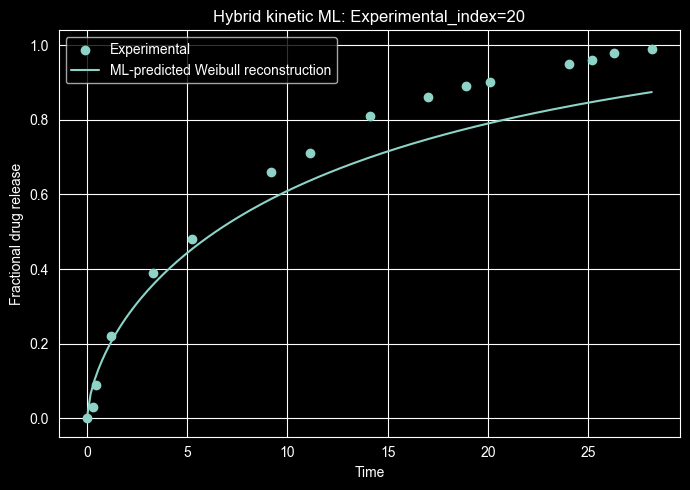

Profile: 20 {'Fmax_pred': np.float64(1.10580030948501), 'tau_pred': np.float64(14.10125381709806), 'beta_pred': np.float64(0.6458111529269468)}


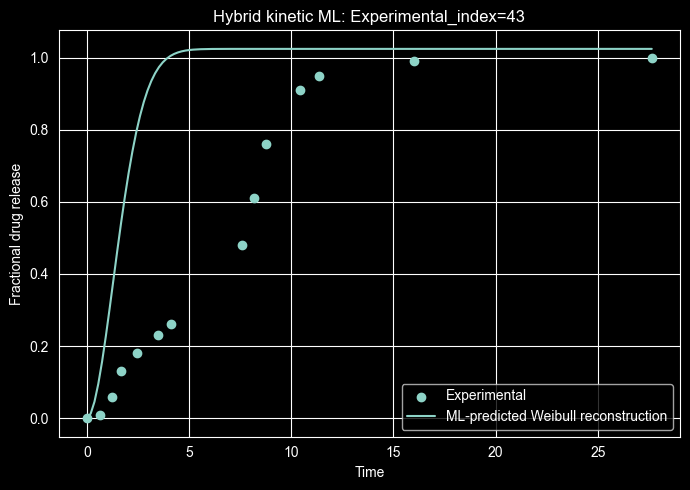

Profile: 43 {'Fmax_pred': np.float64(1.0238955989502465), 'tau_pred': np.float64(1.9492244220609625), 'beta_pred': np.float64(1.8586220053753222)}


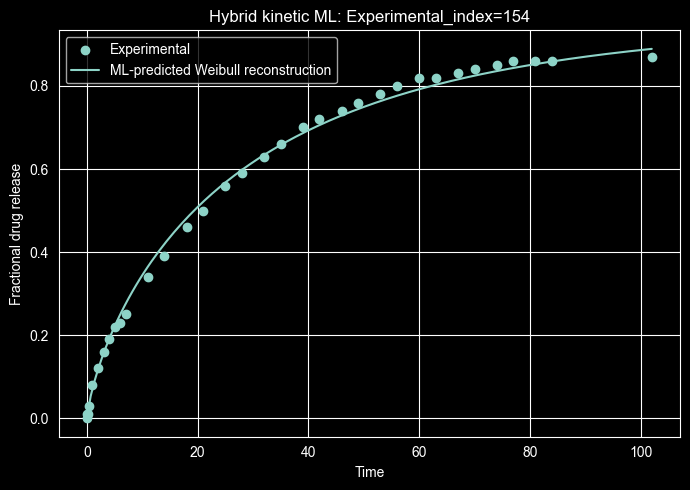

Profile: 154 {'Fmax_pred': np.float64(0.9586968161696282), 'tau_pred': np.float64(28.8516217518485), 'beta_pred': np.float64(0.7638660627029062)}


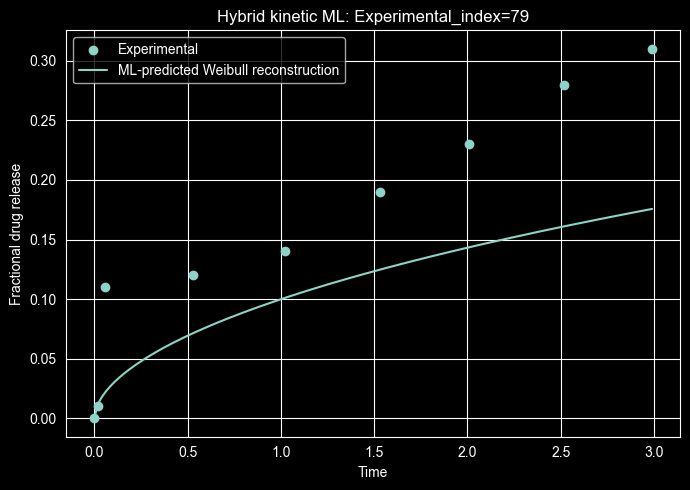

Profile: 79 {'Fmax_pred': np.float64(1.1569904894124152), 'tau_pred': np.float64(79.99148479684274), 'beta_pred': np.float64(0.5487925947672662)}


In [183]:
# Train final parameter model on all profiles for reconstruction examples.
final_param_model = MultiOutputRegressor(
    LGBMRegressor(
        n_estimators=400,
        learning_rate=0.03,
        num_leaves=15,
        min_child_samples=5,
        random_state=RANDOM_STATE,
        verbose=-1
    )
)

final_param_model.fit(
    profile_param_df[FORMULATION_FEATURES_FEW],
    profile_param_df[PARAM_TARGETS]
)

def reconstruct_weibull_curve_from_ml(param_model, profile_param_df, profile_id, t_grid):
    row = profile_param_df[profile_param_df["Experimental_index"] == profile_id].iloc[0]
    X_one = pd.DataFrame([row[FORMULATION_FEATURES_FEW].to_dict()])
    fallback = profile_param_df[PARAM_TARGETS].median().values
    fmax, tau, beta = sanitize_weibull_parameter_predictions(param_model.predict(X_one), fallback)[0]
    y_curve = weibull(t_grid, fmax, tau, beta)
    return y_curve, {"Fmax_pred": fmax, "tau_pred": tau, "beta_pred": beta}

# Plot reconstructed hybrid curves.
hybrid_examples = profile_param_df["Experimental_index"].sample(
    min(4, len(profile_param_df)),
    random_state=RANDOM_STATE
).tolist()

for profile_id in hybrid_examples:
    profile = df[df["Experimental_index"] == profile_id].sort_values("Time")
    t_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), 150)

    y_hybrid, pred_params = reconstruct_weibull_curve_from_ml(
        final_param_model,
        profile_param_df,
        profile_id,
        t_grid
    )

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental")
    plt.plot(t_grid, y_hybrid, label="ML-predicted Weibull reconstruction")
    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Hybrid kinetic ML: Experimental_index={profile_id}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"hybrid_weibull_reconstruction_{profile_id}.png"), dpi=300)
    plt.show()

    print("Profile:", profile_id, pred_params)


### Paper-ready hybrid kinetic ML

The hybrid kinetic ML model reduces each release profile to empirical kinetic parameters and then learns the relationship between formulation descriptors and those parameters. This sacrifices some direct point-wise flexibility but improves interpretability because `Fmax`, `tau`, and `beta` describe the asymptotic release, characteristic release time, and curve shape.

### Optional held-out profile evaluation of the hybrid curve model

This cell predicts Weibull parameters in grouped cross-validation, reconstructs each held-out release curve at the original experimental time points, and computes point-wise release metrics. The primary result uses `Experimental_index`; `DP_Group` can be enabled as a stricter validation check.

In [184]:
def hybrid_weibull_group_cv(profile_df, raw_df, features, targets, group_col=MAIN_GROUP_COL, n_splits=5):
    '''
    Cross-validated hybrid model:
    1. Split profiles.
    2. Train ML to predict Weibull parameters.
    3. Predict parameters for held-out profiles.
    4. Reconstruct release at the original experimental time points.
    '''
    Xp = profile_df[features]
    Yp = profile_df[targets]
    group_values = profile_df[group_col]

    all_pred_rows = []

    base_model = MultiOutputRegressor(
        LGBMRegressor(
            n_estimators=400,
            learning_rate=0.03,
            num_leaves=15,
            min_child_samples=5,
            random_state=RANDOM_STATE,
            verbose=-1
        )
    )

    for fold, (train_idx, test_idx) in enumerate(make_group_splits(Xp, Yp, group_values, n_splits=n_splits)):
        model = clone(base_model)
        train_profiles = profile_df.iloc[train_idx]
        test_profiles = profile_df.iloc[test_idx]

        model.fit(train_profiles[features], train_profiles[targets])

        raw_param_preds = model.predict(test_profiles[features])
        fallback = train_profiles[targets].median().values
        param_preds = sanitize_weibull_parameter_predictions(raw_param_preds, fallback)

        for row_i, (_, profile_row) in enumerate(test_profiles.iterrows()):
            profile_id = profile_row["Experimental_index"]
            fmax, tau, beta = param_preds[row_i]

            raw_profile = raw_df[raw_df["Experimental_index"] == profile_id].copy()
            y_pred = weibull(raw_profile["Time"].values, fmax, tau, beta)

            temp = pd.DataFrame({
                "Experimental_index": profile_id,
                "DP_Group": raw_profile["DP_Group"].values,
                "Time": raw_profile["Time"].values,
                "y_true": raw_profile["Release"].values,
                "y_pred_hybrid": y_pred,
                "fold": fold,
                "group_col": group_col
            })
            all_pred_rows.append(temp)

    pred_df = pd.concat(all_pred_rows, ignore_index=True)
    metrics = regression_metrics(pred_df["y_true"], pred_df["y_pred_hybrid"])
    metrics["group_col"] = group_col
    return metrics, pred_df

hybrid_metrics, hybrid_pred_df = hybrid_weibull_group_cv(
    profile_param_df,
    df,
    FORMULATION_FEATURES_FEW,
    PARAM_TARGETS,
    group_col=MAIN_GROUP_COL,
    n_splits=5
)

display(pd.DataFrame([hybrid_metrics]))
display(hybrid_pred_df.head())

hybrid_pred_df.to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_curve_predictions.csv"), index=False)
pd.DataFrame([hybrid_metrics]).to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_metrics.csv"), index=False)

if RUN_STRICT_DP_GROUP_VALIDATION:
    strict_hybrid_metrics, strict_hybrid_pred_df = hybrid_weibull_group_cv(
        profile_param_df,
        df,
        FORMULATION_FEATURES_FEW,
        PARAM_TARGETS,
        group_col=STRICT_GROUP_COL,
        n_splits=5
    )
    display(pd.DataFrame([strict_hybrid_metrics]))
    strict_hybrid_pred_df.to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_curve_predictions_dp_group.csv"), index=False)
    pd.DataFrame([strict_hybrid_metrics]).to_csv(os.path.join(OUTPUT_DIR, "hybrid_weibull_oof_metrics_dp_group.csv"), index=False)


,MAE,RMSE,R2,group_col
0,0.144068,0.237996,0.475951,Experimental_index


,Experimental_index,DP_Group,Time,y_true,y_pred_hybrid,fold,group_col
0,1,DEX-PEA,0.00,0.00,0.000000,0,Experimental_index
1,1,DEX-PEA,0.17,0.03,0.007506,0,Experimental_index
2,1,DEX-PEA,1.03,0.12,0.031380,0,Experimental_index
3,1,DEX-PEA,3.26,0.20,0.077294,0,Experimental_index
4,1,DEX-PEA,7.04,0.28,0.139126,0,Experimental_index


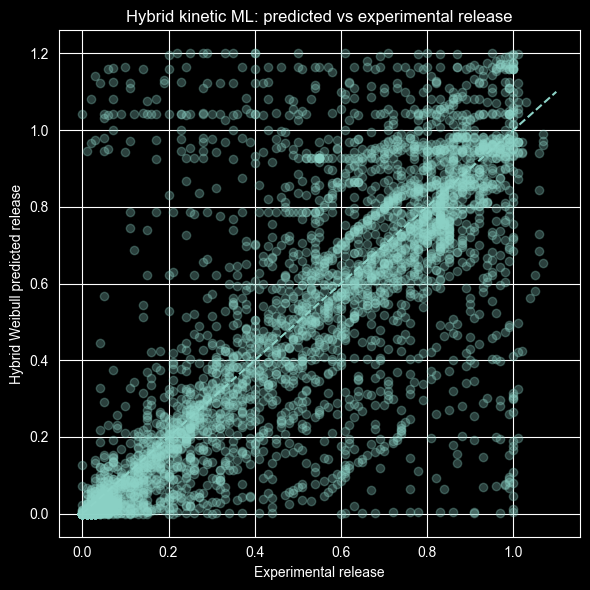

In [185]:
plt.figure(figsize=(6, 6))
plt.scatter(hybrid_pred_df["y_true"], hybrid_pred_df["y_pred_hybrid"], alpha=0.3)
plt.plot([0, 1.1], [0, 1.1], linestyle="--")
plt.xlabel("Experimental release")
plt.ylabel("Hybrid Weibull predicted release")
plt.title("Hybrid kinetic ML: predicted vs experimental release")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "hybrid_weibull_predicted_vs_true.png"), dpi=300)
plt.show()

### Paper-ready direct vs hybrid model comparison

The direct model is expected to achieve stronger point-wise accuracy because it predicts each release observation directly. The hybrid model is useful because it converts each profile into kinetic parameters, making the predicted curve easier to discuss in terms of release extent, characteristic time, and curve shape.

## 9. Uncertainty / monotonic correction

Cumulative release should generally remain bounded and non-decreasing over time. This section applies a post hoc monotonic correction, optionally compares a LightGBM model constrained to be monotonic in `Time`, and estimates simple residual-based prediction intervals from grouped cross-validation errors.

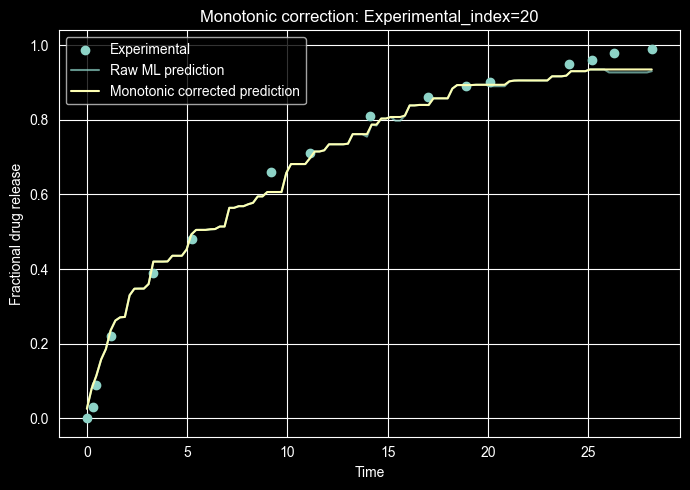

In [186]:
def monotonic_correct(pred, lower=0.0, upper=1.05):
    pred = np.asarray(pred, dtype=float)
    pred = np.clip(pred, lower, upper)
    pred = np.maximum.accumulate(pred)
    return pred

# Example: raw vs corrected prediction
profile_id = example_profiles[0]
profile, time_grid, pred_raw = predict_release_profile(
    best_direct_model,
    df,
    profile_id,
    FEW_SHOT_FEATURES
)

pred_corrected = monotonic_correct(pred_raw)

plt.figure(figsize=(7, 5))
plt.scatter(profile["Time"], profile["Release"], label="Experimental")
plt.plot(time_grid, pred_raw, label="Raw ML prediction", alpha=0.7)
plt.plot(time_grid, pred_corrected, label="Monotonic corrected prediction")
plt.xlabel("Time")
plt.ylabel("Fractional drug release")
plt.title(f"Monotonic correction: Experimental_index={profile_id}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"monotonic_correction_{profile_id}.png"), dpi=300)
plt.show()

### Optional: LightGBM monotonic constraint on `Time`

This forces the model to learn a non-decreasing relationship with `Time`.

Use it as an additional experiment, not necessarily as your main model.

In [187]:
monotone_constraints = [
    1 if feature == "Time" else 0
    for feature in FEW_SHOT_FEATURES
]

monotonic_lgbm = LGBMRegressor(
    n_estimators=700,
    learning_rate=0.025,
    num_leaves=31,
    min_child_samples=10,
    subsample=0.9,
    colsample_bytree=0.9,
    monotone_constraints=monotone_constraints,
    random_state=RANDOM_STATE,
    verbose=-1
)

mono_fold_df, mono_summary, mono_oof = evaluate_group_cv(
    monotonic_lgbm,
    X_few,
    y,
    groups,
    n_splits=5
)

display(pd.DataFrame([
    {"model": "LightGBM raw few-shot", **few_summary},
    {"model": "LightGBM monotonic on Time", **mono_summary}
]))

,model,group_col,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,LightGBM raw few-shot,Experimental_index,0.068674,0.002147,0.103463,0.006623,0.900263,0.012331
1,LightGBM monotonic on Time,Experimental_index,0.081753,0.002756,0.112722,0.005659,0.881876,0.009649


### Paper-ready monotonic correction

Since cumulative release should generally increase over time, predictions were checked for physical plausibility. A post hoc monotonic correction was applied by clipping predictions to a plausible range and enforcing a non-decreasing trajectory. A monotonic LightGBM constraint on `Time` was also evaluated as an optional model-based alternative.

### Simple uncertainty interval from cross-validation residuals

This is not a full Bayesian uncertainty model, but it is simple and useful.

We use cross-validated residuals from the few-shot LightGBM model:
- calculate absolute errors,
- take the 90th percentile,
- use it as an approximate prediction interval width.

Approximate residual interval widths:
80%: 0.11258156282568477
90%: 0.16964104641621286
95%: 0.21601725204901165


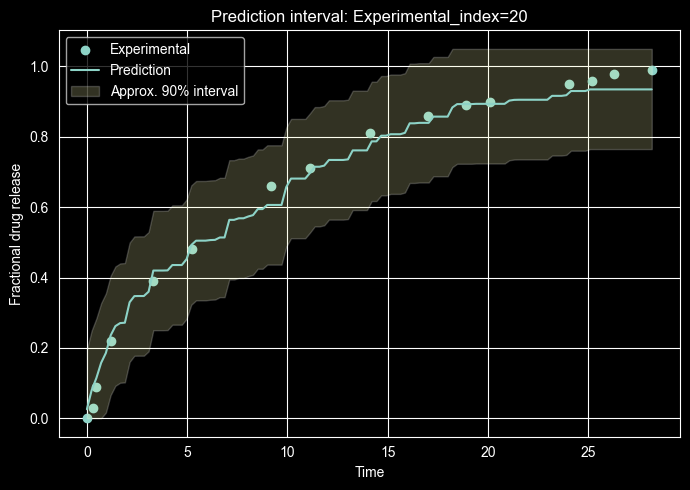

In [188]:
# Absolute residuals from the few-shot OOF predictions
few_oof["abs_error"] = np.abs(few_oof["y_true"] - few_oof["y_pred"])

q80 = np.quantile(few_oof["abs_error"], 0.80)
q90 = np.quantile(few_oof["abs_error"], 0.90)
q95 = np.quantile(few_oof["abs_error"], 0.95)

print("Approximate residual interval widths:")
print("80%:", q80)
print("90%:", q90)
print("95%:", q95)

# Plot one profile with approximate interval.
profile_id = example_profiles[0]
profile, time_grid, pred = predict_release_profile(
    best_direct_model,
    df,
    profile_id,
    FEW_SHOT_FEATURES
)

pred_corr = monotonic_correct(pred)
lower = np.clip(pred_corr - q90, 0, 1.05)
upper = np.clip(pred_corr + q90, 0, 1.05)

plt.figure(figsize=(7, 5))
plt.scatter(profile["Time"], profile["Release"], label="Experimental")
plt.plot(time_grid, pred_corr, label="Prediction")
plt.fill_between(time_grid, lower, upper, alpha=0.2, label="Approx. 90% interval")
plt.xlabel("Time")
plt.ylabel("Fractional drug release")
plt.title(f"Prediction interval: Experimental_index={profile_id}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"prediction_interval_{profile_id}.png"), dpi=300)
plt.show()

### Paper-ready uncertainty statement

Approximate uncertainty intervals were estimated from grouped cross-validation residuals. This empirical approach is not a full probabilistic uncertainty model, but it provides a transparent estimate of prediction error magnitude under the same validation design used for model evaluation.

## 10. Mechanistic chemistry discussion: Polymer_MW, SA-V, DLC, LA/GA, Drug_Mw, Drug_LogP, early burst

This section converts model outputs into chemistry-oriented discussion points. The comments below should be interpreted alongside SHAP rankings, dependence plots, and the known limitations of the dataset.

In [189]:
chemistry_comments = pd.DataFrame([
    {
        "Feature": "Time",
        "Interpretation": "Release should generally increase with time. High SHAP importance confirms that the model learned the kinetic nature of the dataset."
    },
    {
        "Feature": "T=0.25, T=0.5, T=1.0",
        "Interpretation": "Early release values describe the early burst phase. Higher early release usually indicates faster water ingress, surface-associated drug release, or a more open polymer matrix."
    },
    {
        "Feature": "Polymer_MW",
        "Interpretation": "Higher polymer molecular weight can slow water ingress, hydrolysis, polymer erosion, and drug diffusion, often reducing release rate."
    },
    {
        "Feature": "SA-V",
        "Interpretation": "Surface-area-to-volume ratio is linked to particle geometry. Higher SA-V can shorten diffusion distance and increase exposure to release medium."
    },
    {
        "Feature": "DLC",
        "Interpretation": "Drug loading capacity can affect concentration gradient, pore formation, burst release, and drug distribution inside the polymer matrix."
    },
    {
        "Feature": "LA/GA",
        "Interpretation": "The lactide/glycolide ratio affects PLGA hydrophobicity and degradation rate. This should be interpreted carefully because the dataset encodes non-PLGA systems with simplified values."
    },
    {
        "Feature": "Drug_Mw",
        "Interpretation": "Larger molecules may diffuse more slowly through the polymer matrix and can show stronger dependence on polymer morphology."
    },
    {
        "Feature": "Drug_LogP",
        "Interpretation": "Lipophilicity affects drug-polymer affinity and partitioning into the aqueous release medium. More lipophilic drugs may be retained longer in hydrophobic matrices."
    },
    {
        "Feature": "Drug_Pka",
        "Interpretation": "Ionization affects solubility, interaction with polymer end groups, and release into the medium."
    }
])

display(chemistry_comments)
chemistry_comments.to_csv(os.path.join(OUTPUT_DIR, "chemistry_interpretation_comments.csv"), index=False)

,Feature,Interpretation
0,Time,Release should generally increase with time. H...
1,"T=0.25, T=0.5, T=1.0",Early release values describe the early burst ...
2,Polymer_MW,Higher polymer molecular weight can slow water...
3,SA-V,Surface-area-to-volume ratio is linked to part...
4,DLC,Drug loading capacity can affect concentration...
5,LA/GA,The lactide/glycolide ratio affects PLGA hydro...
6,Drug_Mw,Larger molecules may diffuse more slowly throu...
7,Drug_LogP,Lipophilicity affects drug-polymer affinity an...
8,Drug_Pka,"Ionization affects solubility, interaction wit..."


### Paper-ready mechanistic interpretation paragraph

The model did not only learn that release increases with time. SHAP analysis showed that early release measurements, polymer molecular weight, surface-area-to-volume ratio, drug loading, lactide/glycolide ratio, molecular weight, and lipophilicity contributed to predictions. These effects are chemically plausible: polymer molecular weight and LA/GA composition can affect degradation and water uptake, SA-V changes diffusion geometry, DLC influences concentration gradients and burst release, and drug molecular descriptors affect diffusion, solubility, and drug-polymer affinity.

### Counterfactual sensitivity analysis

This is optional but useful for the discussion.

For one selected profile, we change one feature at a time and predict how the release curve changes.

Important wording:
- Do **not** say this proves causality.
- Say it is **model-based counterfactual sensitivity analysis**.

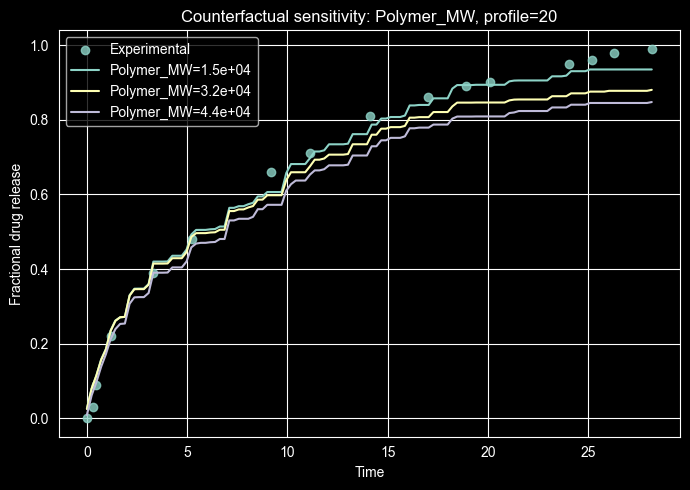

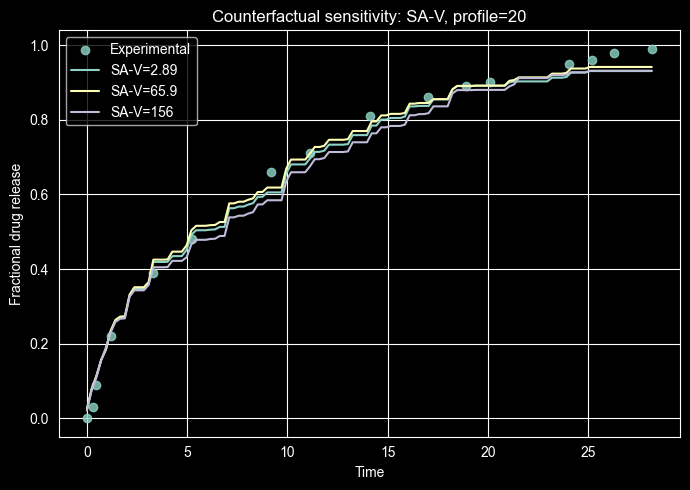

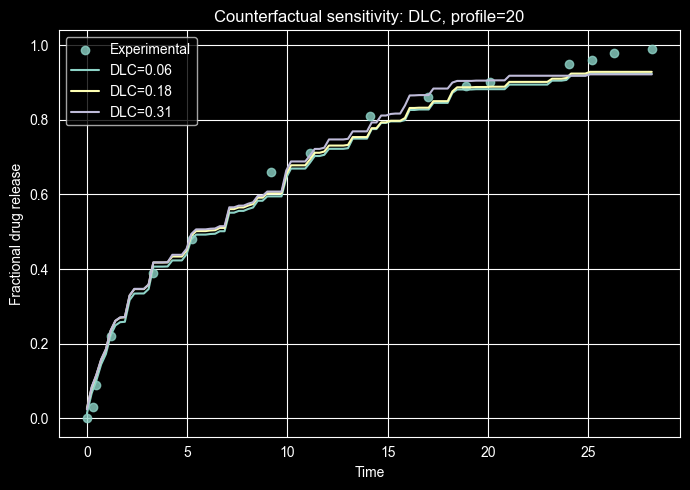

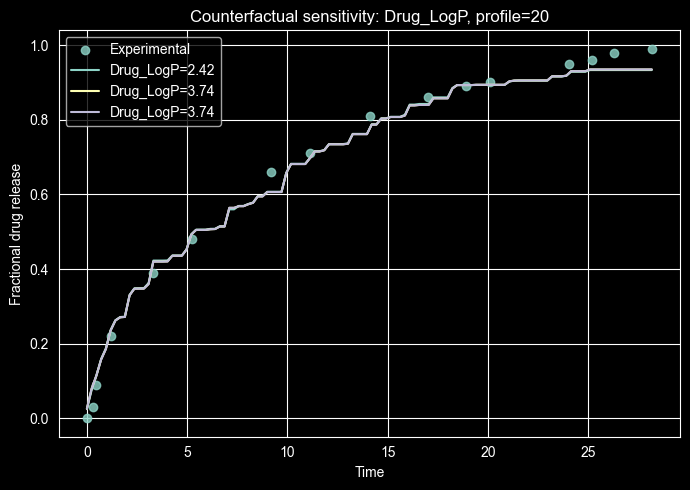

In [190]:
def counterfactual_profile_plot(model, data, profile_id, features, feature_to_change, values, n_points=120):
    profile = data[data["Experimental_index"] == profile_id].sort_values("Time").copy()
    base_row = profile.iloc[0].copy()
    time_grid = np.linspace(profile["Time"].min(), profile["Time"].max(), n_points)

    plt.figure(figsize=(7, 5))
    plt.scatter(profile["Time"], profile["Release"], label="Experimental", alpha=0.8)

    for value in values:
        X_grid = pd.DataFrame([base_row[features].to_dict()] * n_points)
        X_grid["Time"] = time_grid
        X_grid[feature_to_change] = value

        pred = model.predict(X_grid[features])
        pred = monotonic_correct(pred)

        plt.plot(time_grid, pred, label=f"{feature_to_change}={value:.3g}")

    plt.xlabel("Time")
    plt.ylabel("Fractional drug release")
    plt.title(f"Counterfactual sensitivity: {feature_to_change}, profile={profile_id}")
    plt.legend()
    plt.tight_layout()
    safe_name = feature_to_change.replace("/", "_").replace("=", "").replace(" ", "_")
    plt.savefig(os.path.join(OUTPUT_DIR, f"counterfactual_{safe_name}_{profile_id}.png"), dpi=300)
    plt.show()

profile_id = example_profiles[0]

# Choose realistic values from quantiles in the dataset.
for feature_to_change in ["Polymer_MW", "SA-V", "DLC", "Drug_LogP"]:
    if feature_to_change in FEW_SHOT_FEATURES:
        values = df[feature_to_change].quantile([0.25, 0.50, 0.75]).values
        counterfactual_profile_plot(
            best_direct_model,
            df,
            profile_id,
            FEW_SHOT_FEATURES,
            feature_to_change,
            values
        )

### Paper-ready counterfactual analysis

A model-based counterfactual sensitivity analysis was performed by fixing one formulation profile and changing selected chemistry descriptors across realistic dataset quantiles. These plots are not causal proof, but they help visualize how the trained model associates `Polymer_MW`, `SA-V`, `DLC`, and `Drug_LogP` with release-profile shape.

### Suggested final paper structure

Use this structure to mirror the notebook:

1. **Introduction**: LAI systems, release prediction difficulty, and the motivation for explainable ML.
2. **Dataset and preliminary Orange baseline**: dataset description, Orange EDA/modeling context, and why grouped validation is needed.
3. **Python reproducible workflow**: data loading, feature definitions, EDA, VIF, and `Experimental_index` grouped validation.
4. **Baseline model comparison**: Ridge, PLS, Random Forest, Gradient Boosting, XGBoost, LightGBM, and CatBoost.
5. **Zero-shot vs few-shot prediction**: descriptor-only prediction versus prediction with early release values, using the better grouped-CV model between LightGBM and CatBoost.
6. **Full release profile prediction**: fix formulation descriptors and vary only `Time`.
7. **SHAP explainability**: global and feature-level interpretation for the selected LightGBM/CatBoost model.
8. **Hybrid kinetic ML**: Weibull/logistic fitting, kinetic parameter prediction, and curve reconstruction.
9. **Uncertainty / monotonic correction**: monotonic post-processing, optional monotonic constraints, and residual intervals.
10. **Mechanistic chemistry discussion**: Polymer_MW, SA-V, DLC, LA/GA, Drug_Mw, Drug_LogP, and early burst.

### Exported files

All figures and tables are saved in `lai_outputs/`. These outputs can be used directly when drafting the paper, with the grouped-validation setting reported alongside the corresponding metrics.

In [191]:
print("Saved output files:")
for file in sorted(os.listdir(OUTPUT_DIR)):
    print(file)

Saved output files:
baseline_groupcv_results.csv
baseline_model_comparison_mae.png
chemistry_interpretation_comments.csv
counterfactual_DLC_20.png
counterfactual_Drug_LogP_20.png
counterfactual_Polymer_MW_20.png
counterfactual_SA-V_20.png
feature_distributions_by_profile
few_shot_oof_predictions.csv
hybrid_weibull_oof_curve_predictions.csv
hybrid_weibull_oof_metrics.csv
hybrid_weibull_predicted_vs_true.png
hybrid_weibull_reconstruction_154.png
hybrid_weibull_reconstruction_20.png
hybrid_weibull_reconstruction_43.png
hybrid_weibull_reconstruction_79.png
kinetic_curve_fit_parameters.csv
kinetic_fit_154.png
kinetic_fit_20.png
kinetic_fit_43.png
kinetic_fit_79.png
lightgbm_vs_catboost_groupcv_results.csv
missing_values.csv
monotonic_correction_20.png
prediction_interval_20.png
profile_prediction_154.png
profile_prediction_20.png
profile_prediction_43.png
profile_prediction_79.png
release_histogram_by_dp_group_overview.png
release_histograms_by_dp_group
release_histograms_by_group
release_h